In [1]:
import sys
sys.path.insert(0, "/Users/matt.holden/Projects/tennis-origination")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from injestion.core.bq import get_client
from injestion.sportradar import SportradarManager
from injestion.oddsjam import OddsJamManager
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)


In [2]:
bq_client = get_client()
sr_manager = SportradarManager()
oj_manager = OddsJamManager()

In [3]:
def get_pbp_data() -> pd.DataFrame:
    event_timeline_table_id = sr_manager.get_table_id("event_timeline")
    query = f"""
    SELECT * FROM `{event_timeline_table_id}`
    """
    return bq_client.query(query).to_dataframe()

pbp = get_pbp_data()
pbp = pbp[~pbp.timeline_not_available]


In [4]:
def get_event_summary_data() -> pd.DataFrame:
    event_summary_table_id = sr_manager.get_table_id("event_summary")
    query = f"""
    SELECT * FROM `{event_summary_table_id}`
    """
    return bq_client.query(query).to_dataframe()

event_summary = get_event_summary_data()

event_summary["total_sets"] = event_summary["home_score"] + event_summary["away_score"]


In [5]:
def get_event_statistics_data() -> pd.DataFrame:
    event_statistics_table_id = sr_manager.get_table_id("event_statistics")
    query = f"""
    SELECT * FROM `{event_statistics_table_id}`
    """
    return bq_client.query(query).to_dataframe()

event_statistics = get_event_statistics_data()

_______

Odds Data

In [6]:
def get_aces_odds_data() -> pd.DataFrame:
    aces_odds_table_id = oj_manager.get_table_id("oddsjam_odds")
    query = f"""
    SELECT * FROM `{aces_odds_table_id}` where market = 'Player Aces'
    """
    return bq_client.query(query).to_dataframe()

aces_odds_data = get_aces_odds_data()


In [7]:
def get_fixtures_data(fixture_ids: list[str]) -> pd.DataFrame:
    if not fixture_ids:
        return pd.DataFrame()
    fixtures_table_id = oj_manager.get_table_id("oddsjam_fixtures")
    id_list = ", ".join(f"'{str(fid)}'" for fid in fixture_ids)
    query = f"""
    SELECT * FROM `{fixtures_table_id}` WHERE id IN ({id_list})
    """
    return bq_client.query(query).to_dataframe()

fixture_ids = list(aces_odds_data["fixture_id"].unique())
fixtures_data = get_fixtures_data(fixture_ids)


In [8]:
aces_odds_over = aces_odds_data[aces_odds_data["selection_line"] == "over"]

avg_by_fixture_selection = (
    aces_odds_over
    .groupby(["fixture_id", "normalized_selection"], as_index=False)
    .agg(
        avg_closing_line_price=("closing_line_price", "mean"),
        avg_closing_line_points=("closing_line_points", "mean"),
    )
)
aces_odds_over = aces_odds_over.merge(
    avg_by_fixture_selection, on=["fixture_id", "normalized_selection"], how="left"
)

In [9]:
aces_odds_over.head()

,fixture_id,game_id,home_competitor_names,home_competitor_ids,away_competitor_names,away_competitor_ids,status,is_live,season_type,season_year,season_week,venue_name,venue_location,league_id,league_name,odds_id,sportsbook,market,market_id,name,selection,normalized_selection,selection_line,is_main,player_id,team_id,opening_line_price,opening_line_points,closing_line_price,closing_line_points,no_odds,avg_closing_line_price,avg_closing_line_points
0,32A599D80A5E,11367-30104-2024-51,[Arthur Fils],[4AAE59D669DA],[Jakub Mensik],[76317ADC22CA],completed,False,Next Gen ATP Finals presented by PIF 2024,ATP World Tour 2024,group stage,None,"Jeddah, Saudi Arabia",atp,ATP,11367-30104-2024-51:draftkings:player_aces:art...,DraftKings,Player Aces,player_aces,Arthur Fils over,Arthur Fils,arthur_fils,over,True,None,None,-110.0,9.5,-110.0,9.5,False,-110.0,9.5
1,32A599D80A5E,11367-30104-2024-51,[Arthur Fils],[4AAE59D669DA],[Jakub Mensik],[76317ADC22CA],completed,False,Next Gen ATP Finals presented by PIF 2024,ATP World Tour 2024,group stage,None,"Jeddah, Saudi Arabia",atp,ATP,11367-30104-2024-51:draftkings:player_aces:jak...,DraftKings,Player Aces,player_aces,Jakub Mensik over,Jakub Mensik,jakub_mensik,over,True,None,None,-120.0,11.5,-120.0,11.5,False,-120.0,11.5
2,atp:A54D56C641F6,29740-10679-2025-03,[Jannik Sinner],[93CA2DD0F3BF],[Alexander Zverev],[7DF27096EABA],completed,False,Australian Open 2025,ATP World Tour 2025,final,None,"Melbourne, Australia",atp,ATP,29740-10679-2025-03:draftkings:player_aces:ale...,DraftKings,Player Aces,player_aces,Alexander Zverev over,Alexander Zverev,alexander_zverev,over,True,None,None,-120.0,12.5,-120.0,12.5,False,-120.0,12.5
3,atp:A54D56C641F6,29740-10679-2025-03,[Jannik Sinner],[93CA2DD0F3BF],[Alexander Zverev],[7DF27096EABA],completed,False,Australian Open 2025,ATP World Tour 2025,final,None,"Melbourne, Australia",atp,ATP,29740-10679-2025-03:draftkings:player_aces:jan...,DraftKings,Player Aces,player_aces,Jannik Sinner over,Jannik Sinner,jannik_sinner,over,True,None,None,-120.0,9.5,100.0,10.5,False,100.0,10.5
4,atp:6785DD85E037,31209-13833-2025-04,[Aleksandar Kovacevic],[6D95CAF2DE93],[Felix Auger-Aliassime],[F7A15AEDB72E],completed,False,Open Occitanie 2025,ATP World Tour 2025,final,None,"Montpellier, France",atp,ATP,31209-13833-2025-04:draftkings:player_aces:ale...,DraftKings,Player Aces,player_aces,Aleksandar Kovacevic over,Aleksandar Kovacevic,aleksandar_kovacevic,over,True,None,None,-120.0,8.5,-120.0,8.5,False,-120.0,8.5


___

In [10]:
import re

def name_to_regex(name: str) -> str:
    """Build a regex so 'First Last' matches 'First Last', 'Last First', or 'First X Last'."""
    name = str(name).strip()
    if not name:
        return ""
    parts = name.split()
    if len(parts) == 1:
        return re.escape(parts[0])
    escaped = [re.escape(p) for p in parts]
    if len(parts) == 2:
        return f"{escaped[0]}.*{escaped[1]}|{escaped[1]}.*{escaped[0]}"
    # 3+ words: allow first/last in either order
    return f"{escaped[0]}.*{escaped[-1]}|{escaped[-1]}.*{escaped[0]}"

In [11]:
def find_matching_sport_event_id(
    fixture_row: pd.Series,
    event_summary: pd.DataFrame,
) -> str | None:
    """Find a sport_event_id in event_summary that matches the fixture by loose names and date. Returns None if no match."""
    home_display = fixture_row.get("home_team_display")
    away_display = fixture_row.get("away_team_display")
    start_date = fixture_row.get("start_date")

    if pd.isna(home_display) or pd.isna(away_display) or pd.isna(start_date):
        return None

    target_date = pd.to_datetime(start_date, utc=True).date()
    es_date = pd.to_datetime(event_summary["start_time"], utc=True).dt.date
    date_mask = es_date == target_date

    name1 = str(home_display).strip()
    name2 = str(away_display).strip()
    pattern1 = name_to_regex(name1)
    pattern2 = name_to_regex(name2)
    if not pattern1 or not pattern2:
        return None

    home_has_1 = event_summary["home_competitor_name"].str.contains(pattern1, case=False, na=False, regex=True)
    away_has_2 = event_summary["away_competitor_name"].str.contains(pattern2, case=False, na=False, regex=True)
    home_has_2 = event_summary["home_competitor_name"].str.contains(pattern2, case=False, na=False, regex=True)
    away_has_1 = event_summary["away_competitor_name"].str.contains(pattern1, case=False, na=False, regex=True)
    player_mask = (home_has_1 & away_has_2) | (home_has_2 & away_has_1)

    combined = date_mask & player_mask
    matched = event_summary.loc[combined]
    if matched.empty:
        return None
    return matched["sport_event_id"].iloc[0]

In [12]:
def build_fixture_to_sport_event_map(
    fixtures_data: pd.DataFrame,
    event_summary: pd.DataFrame,
) -> pd.DataFrame:
    """Left-merge fixtures_data to event_summary by loose name + date. Returns DataFrame with fixture_id and sport_event_id."""
    rows = []
    for _, row in fixtures_data.iterrows():
        fixture_id = row["id"]
        sport_event_id = find_matching_sport_event_id(row, event_summary)
        rows.append({"fixture_id": fixture_id, "sport_event_id": sport_event_id})
    return pd.DataFrame(rows)

In [13]:
def build_name_matching_df(
    fixture_to_sport_event: pd.DataFrame,
    fixtures_data: pd.DataFrame,
    event_summary: pd.DataFrame,
) -> pd.DataFrame:
    """Build a dataframe with one row per player: maps OddsJam player name to Sportradar player name.
    Columns: fixture_id, sport_event_id, oj_player_name, sr_player_name, role (home/away).
    """
    matched = fixture_to_sport_event[fixture_to_sport_event["sport_event_id"].notna()].copy()
    oj = fixtures_data[["id", "home_team_display", "away_team_display"]].rename(
        columns={"id": "fixture_id"}
    )
    sr = event_summary[["sport_event_id", "home_competitor_name", "away_competitor_name"]].drop_duplicates(
        subset="sport_event_id"
    )

    df = matched.merge(oj, on="fixture_id", how="left").merge(sr, on="sport_event_id", how="left")

    # Long form: one row per player
    home = df[["fixture_id", "sport_event_id", "home_team_display", "home_competitor_name"]].rename(
        columns={"home_team_display": "oj_player_name", "home_competitor_name": "sr_player_name"}
    )
    home["role"] = "home"

    away = df[["fixture_id", "sport_event_id", "away_team_display", "away_competitor_name"]].rename(
        columns={"away_team_display": "oj_player_name", "away_competitor_name": "sr_player_name"}
    )
    away["role"] = "away"

    return pd.concat([home, away], ignore_index=True)

In [14]:
fixture_to_sport_event = build_fixture_to_sport_event_map(fixtures_data, event_summary)
name_matching_df = build_name_matching_df(fixture_to_sport_event, fixtures_data, event_summary)

In [15]:
# The fixtures that have odds but no event summary (sportradar)
fixture_to_sport_event[fixture_to_sport_event.sport_event_id.isna()]

,fixture_id,sport_event_id
0,6FFBBE61E533,None
1,FD0690648821,None
2,D4C63531D676,None
3,0038CFAB1598,None
4,32A599D80A5E,None
5,60E657C10349,None
6,080FBFF06636,None
33,20250323CE595077,None
67,202512173C67F575,None


______

Data Processing

In [16]:
def assign_set_from_period_starts(match_timeline: pd.DataFrame) -> pd.Series:
    """Assign set number (period) to each event. One match's rows only."""
    df = match_timeline.sort_values("event_order")
    current_period = None
    started = False
    ended = False
    suspended = False
    periods = []
    for _, row in df.iterrows():
        if row["type"] == "match_started":
            started = True
            periods.append(None)
        elif row["type"] == "match_ended":
            periods.append(None)
            ended = True
        elif not started or ended:
            periods.append(None)
        elif row["type"] == "match_suspended":
            suspended = True
            periods.append(current_period if current_period is None else int(current_period))
        elif suspended and row["type"] == "period_start":
            suspended = False
            periods.append(current_period if current_period is None else int(current_period))
        elif row["type"] == "period_start":
            current_period = (current_period + 1) if current_period is not None else 1
            periods.append(current_period)
        else:
            periods.append(current_period if current_period is None else int(current_period))
    return pd.Series(periods, index=df.index)


In [17]:
def assign_set_from_period_scores(match_timeline: pd.DataFrame) -> pd.Series:
    """
    Infer set number from period_score events only. Use when period_start is missing.
    Only events between match_started and match_ended (inclusive) get a period;
    events before match_started or after match_ended get None.
    A period_score row is the last point of the set; the next row starts the new set.
    """
    df = match_timeline.sort_values("event_order")
    current_period = None
    started = False
    ended = False
    periods = []
    for _, row in df.iterrows():
        if row["type"] == "match_started":
            started = True
            current_period = 1
            periods.append(None)
        elif row["type"] == "match_ended":
            periods.append(None)
            ended = True
        elif not started or ended:
            periods.append(None)
        else:
            periods.append(int(current_period))
            if row["type"] == "period_score":
                h, a = row.get("home_score"), row.get("away_score")
                if pd.notna(h) and pd.notna(a):
                    if max(h, a) == 7 or (max(h, a) == 6 and abs(h - a) >= 2):
                        current_period += 1
    return pd.Series(periods, index=df.index)

In [18]:
def assign_set_null(match_timeline: pd.DataFrame) -> pd.Series:
    return pd.Series(None, index=match_timeline.index)


In [19]:
def assign_set(match_timeline: pd.DataFrame, total_sets: int | None) -> pd.Series:
    if pd.isna(total_sets):
        period_series = assign_set_null(match_timeline)
    else:
        period_series = assign_set_from_period_starts(match_timeline)
        sport_event_id = match_timeline["sport_event_id"].iloc[0]
        if total_sets is not None:
            max_period = period_series.max()
            if pd.isna(max_period) or max_period != total_sets:
                period_series = assign_set_from_period_scores(match_timeline)
                max_period = period_series.max()
                if pd.isna(max_period) or max_period != total_sets:
                    print(f"Failed to assign set for sport_event_id: {sport_event_id}, max_period: {max_period}, total_sets: {total_sets}")
                    period_series = assign_set_null(match_timeline)
    return period_series

In [20]:
pbp_sorted = pbp.sort_values(["sport_event_id", "event_order"])
# merge so each timeline row has total_sets
pbp_with_total = pbp_sorted.merge(
    event_summary[["sport_event_id", "total_sets", "match_status"]],
    on="sport_event_id",
    how="left",
)

pbp_with_total = pbp_with_total[pbp_with_total["match_status"] != "retired"]

# building period column by sport_event_id
parts = []
for sid, grp in pbp_with_total.groupby("sport_event_id", sort=False):
    total_sets = grp["total_sets"].iloc[0] if "total_sets" in grp.columns else None
    total_sets = int(total_sets) if pd.notna(total_sets) else None
    parts.append(assign_set(grp, total_sets=total_sets))
period_series = pd.concat(parts)
pbp_with_total["period"] = period_series

# remove rows where period is not assigned
pbp_with_total = pbp_with_total[
    pbp_with_total.groupby("sport_event_id")["period"].transform(lambda s: s.notna().any())
]

Failed to assign set for sport_event_id: sr:sport_event:58856555, max_period: 1.0, total_sets: 2
Failed to assign set for sport_event_id: sr:sport_event:59152417, max_period: nan, total_sets: 3
Failed to assign set for sport_event_id: sr:sport_event:59276549, max_period: nan, total_sets: 2
Failed to assign set for sport_event_id: sr:sport_event:59410453, max_period: nan, total_sets: 3
Failed to assign set for sport_event_id: sr:sport_event:59521813, max_period: nan, total_sets: 2
Failed to assign set for sport_event_id: sr:sport_event:59816634, max_period: nan, total_sets: 2
Failed to assign set for sport_event_id: sr:sport_event:61073927, max_period: nan, total_sets: 2
Failed to assign set for sport_event_id: sr:sport_event:61213687, max_period: nan, total_sets: 3
Failed to assign set for sport_event_id: sr:sport_event:62476956, max_period: 3.0, total_sets: 2
Failed to assign set for sport_event_id: sr:sport_event:62477534, max_period: 4.0, total_sets: 3
Failed to assign set for sport

_________
Aces Count DF

In [21]:
def ace_share_by_set(match_timeline: pd.DataFrame) -> pd.DataFrame:
    """
    For one match's timeline (with period column set), return two rows (home/away) with
    sport_event_id, server, 1st–5th set ace shares, and 1st–5th set ace counts.
    Sets not played: share and count are null / 0 as below.
    """
    sport_event_id = match_timeline["sport_event_id"].iloc[0]
    aces = match_timeline[match_timeline["result"] == "ace"]
    period = match_timeline["period"].dropna()
    sets_played = int(period.astype(int).max()) if len(period) else 0

    share_cols = ["1st set ace share", "2nd set ace share", "3rd set ace share", "4th set ace share", "5th set ace share"]
    count_cols = ["1st set ace count", "2nd set ace count", "3rd set ace count", "4th set ace count", "5th set ace count"]
    rows = []

    for server in ["home", "away"]:
        server_aces = aces[aces["server"] == server]
        total_aces = len(server_aces)
        row = {"sport_event_id": sport_event_id, "server": server}
        for i in range(1, 6):
            count_in_set = len(server_aces[server_aces["period"].astype(int) == i])
            row[count_cols[i - 1]] = count_in_set if i <= sets_played else None
            if i > sets_played:
                row[share_cols[i - 1]] = None
            elif total_aces == 0:
                row[share_cols[i - 1]] = 0.0
            else:
                row[share_cols[i - 1]] = count_in_set / total_aces
        rows.append(row)
    return pd.DataFrame(rows)

def build_ace_share_df(timeline_df: pd.DataFrame) -> pd.DataFrame:
    """Requires timeline_df to have period already filled (e.g. from your vectorized fill)."""
    parts = [
        ace_share_by_set(grp)
        for _, grp in timeline_df.groupby("sport_event_id", sort=False)
    ]
    return pd.concat(parts, ignore_index=True)

In [22]:
parts = []
for sid, grp in pbp_with_total.groupby("sport_event_id", sort=False):
    try:
        parts.append(ace_share_by_set(grp))
    except Exception as e:
        print(f"sport_event_id: {sid}")
        print(f"  Error: {e}")

ace_share_df = pd.concat(parts, ignore_index=True)
        

/var/folders/wj/3h07_z2d5xg4t2fzhqx3f0j00000gp/T/ipykernel_3577/1205621719.py:9: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  ace_share_df = pd.concat(parts, ignore_index=True)


In [23]:
ace_share_df.head()

,sport_event_id,server,1st set ace count,1st set ace share,2nd set ace count,2nd set ace share,3rd set ace count,3rd set ace share,4th set ace count,4th set ace share,5th set ace count,5th set ace share
0,sr:sport_event:58211283,home,3,1.000000,0,0.000000,None,NaN,None,NaN,None,NaN
1,sr:sport_event:58211283,away,0,0.000000,1,1.000000,None,NaN,None,NaN,None,NaN
2,sr:sport_event:58211287,home,2,0.666667,1,0.333333,0,0.0,None,NaN,None,NaN
3,sr:sport_event:58211287,away,1,0.500000,1,0.500000,0,0.0,None,NaN,None,NaN
4,sr:sport_event:58211289,home,2,0.166667,10,0.833333,None,NaN,None,NaN,None,NaN


In [24]:
# columns needed:
# total_sets - for splitting analysis by number of sets played
# mode_best_of - for splitting analysis by best of
# home/away competitor names - for identifying the server to merge with player odds
merged_ace_share = ace_share_df.merge(
    event_summary[["sport_event_id", "total_sets", "mode_best_of", "home_competitor_name", "away_competitor_name"]], on="sport_event_id", how="left"
)

# total aces
count_cols = ["1st set ace count", "2nd set ace count", "3rd set ace count", "4th set ace count", "5th set ace count"]
merged_ace_share["total_aces"] = merged_ace_share[count_cols].sum(axis=1)

# server competitor name
merged_ace_share["server_competitor_name"] = np.where(
    merged_ace_share["server"] == "home",  # use your actual column name
    merged_ace_share["home_competitor_name"],
    merged_ace_share["away_competitor_name"],
)

In [25]:
merged_ace_share.head()

,sport_event_id,server,1st set ace count,1st set ace share,2nd set ace count,2nd set ace share,3rd set ace count,3rd set ace share,4th set ace count,4th set ace share,5th set ace count,5th set ace share,total_sets,mode_best_of,home_competitor_name,away_competitor_name,total_aces,server_competitor_name
0,sr:sport_event:58211283,home,3,1.000000,0,0.000000,None,NaN,None,NaN,None,NaN,2,3,"Tien, Learner","Machac, Tomas",3,"Tien, Learner"
1,sr:sport_event:58211283,away,0,0.000000,1,1.000000,None,NaN,None,NaN,None,NaN,2,3,"Tien, Learner","Machac, Tomas",1,"Machac, Tomas"
2,sr:sport_event:58211287,home,2,0.666667,1,0.333333,0,0.0,None,NaN,None,NaN,3,3,"Shapovalov, Denis","Giron, Marcos",3,"Shapovalov, Denis"
3,sr:sport_event:58211287,away,1,0.500000,1,0.500000,0,0.0,None,NaN,None,NaN,3,3,"Shapovalov, Denis","Giron, Marcos",2,"Giron, Marcos"
4,sr:sport_event:58211289,home,2,0.166667,10,0.833333,None,NaN,None,NaN,None,NaN,2,3,"Nakashima, Brandon","Goffin, David",12,"Nakashima, Brandon"


_________
Betting Line vs Actual

In [26]:
# aces odds data per player/match
aces_odds_over.head()

,fixture_id,game_id,home_competitor_names,home_competitor_ids,away_competitor_names,away_competitor_ids,status,is_live,season_type,season_year,season_week,venue_name,venue_location,league_id,league_name,odds_id,sportsbook,market,market_id,name,selection,normalized_selection,selection_line,is_main,player_id,team_id,opening_line_price,opening_line_points,closing_line_price,closing_line_points,no_odds,avg_closing_line_price,avg_closing_line_points
0,32A599D80A5E,11367-30104-2024-51,[Arthur Fils],[4AAE59D669DA],[Jakub Mensik],[76317ADC22CA],completed,False,Next Gen ATP Finals presented by PIF 2024,ATP World Tour 2024,group stage,None,"Jeddah, Saudi Arabia",atp,ATP,11367-30104-2024-51:draftkings:player_aces:art...,DraftKings,Player Aces,player_aces,Arthur Fils over,Arthur Fils,arthur_fils,over,True,None,None,-110.0,9.5,-110.0,9.5,False,-110.0,9.5
1,32A599D80A5E,11367-30104-2024-51,[Arthur Fils],[4AAE59D669DA],[Jakub Mensik],[76317ADC22CA],completed,False,Next Gen ATP Finals presented by PIF 2024,ATP World Tour 2024,group stage,None,"Jeddah, Saudi Arabia",atp,ATP,11367-30104-2024-51:draftkings:player_aces:jak...,DraftKings,Player Aces,player_aces,Jakub Mensik over,Jakub Mensik,jakub_mensik,over,True,None,None,-120.0,11.5,-120.0,11.5,False,-120.0,11.5
2,atp:A54D56C641F6,29740-10679-2025-03,[Jannik Sinner],[93CA2DD0F3BF],[Alexander Zverev],[7DF27096EABA],completed,False,Australian Open 2025,ATP World Tour 2025,final,None,"Melbourne, Australia",atp,ATP,29740-10679-2025-03:draftkings:player_aces:ale...,DraftKings,Player Aces,player_aces,Alexander Zverev over,Alexander Zverev,alexander_zverev,over,True,None,None,-120.0,12.5,-120.0,12.5,False,-120.0,12.5
3,atp:A54D56C641F6,29740-10679-2025-03,[Jannik Sinner],[93CA2DD0F3BF],[Alexander Zverev],[7DF27096EABA],completed,False,Australian Open 2025,ATP World Tour 2025,final,None,"Melbourne, Australia",atp,ATP,29740-10679-2025-03:draftkings:player_aces:jan...,DraftKings,Player Aces,player_aces,Jannik Sinner over,Jannik Sinner,jannik_sinner,over,True,None,None,-120.0,9.5,100.0,10.5,False,100.0,10.5
4,atp:6785DD85E037,31209-13833-2025-04,[Aleksandar Kovacevic],[6D95CAF2DE93],[Felix Auger-Aliassime],[F7A15AEDB72E],completed,False,Open Occitanie 2025,ATP World Tour 2025,final,None,"Montpellier, France",atp,ATP,31209-13833-2025-04:draftkings:player_aces:ale...,DraftKings,Player Aces,player_aces,Aleksandar Kovacevic over,Aleksandar Kovacevic,aleksandar_kovacevic,over,True,None,None,-120.0,8.5,-120.0,8.5,False,-120.0,8.5


In [27]:
# attach sportradar player name to the odds data
odds_with_sr = aces_odds_over.merge(
    name_matching_df[["fixture_id", "oj_player_name", "sport_event_id", "sr_player_name"]],
    left_on=["fixture_id", "selection"],
    right_on=["fixture_id", "oj_player_name"],
    how="left",
)

# merge with sportradar aces data using sport event id and sportradar player name
stats_and_odds_df = odds_with_sr.merge(
    merged_ace_share,
    left_on=["sport_event_id", "sr_player_name"],
    right_on=["sport_event_id", "server_competitor_name"],
    how="left",
)


In [28]:
# not all odds matches have play by play aces data
stats_and_odds_clean_df = stats_and_odds_df[stats_and_odds_df['1st set ace share'].notna()]
stats_and_odds_clean_df.head()

,fixture_id,game_id,home_competitor_names,home_competitor_ids,away_competitor_names,away_competitor_ids,status,is_live,season_type,season_year,season_week,venue_name,venue_location,league_id,league_name,odds_id,sportsbook,market,market_id,name,selection,normalized_selection,selection_line,is_main,player_id,team_id,opening_line_price,opening_line_points,closing_line_price,closing_line_points,no_odds,avg_closing_line_price,avg_closing_line_points,oj_player_name,sport_event_id,sr_player_name,server,1st set ace count,1st set ace share,2nd set ace count,2nd set ace share,3rd set ace count,3rd set ace share,4th set ace count,4th set ace share,5th set ace count,5th set ace share,total_sets,mode_best_of,home_competitor_name,away_competitor_name,total_aces,server_competitor_name
8,2025031169E04A12,34964-14624-2025-10,[Tallon Griekspoor],[EA01FCBDC3F7],[Yosuke Watanuki],[2F74B6ED2E7F],completed,False,"Indian Wells, USA",2025,round of 16,Stadium 2,"Indian Wells, CA, USA",atp,ATP,34964-14624-2025-10:draftkings:player_aces:tal...,DraftKings,Player Aces,player_aces,Tallon Griekspoor over,Tallon Griekspoor,tallon_griekspoor,over,True,None,None,-140.0,7.5,-140.0,7.5,False,-140.0,7.5,Tallon Griekspoor,sr:sport_event:58399661,"Griekspoor, Tallon",home,2.0,0.666667,1,0.333333,None,NaN,None,NaN,None,NaN,2,3,"Griekspoor, Tallon","Watanuki, Yosuke",3,"Griekspoor, Tallon"
9,2025031169E04A12,34964-14624-2025-10,[Tallon Griekspoor],[EA01FCBDC3F7],[Yosuke Watanuki],[2F74B6ED2E7F],completed,False,"Indian Wells, USA",2025,round of 16,Stadium 2,"Indian Wells, CA, USA",atp,ATP,34964-14624-2025-10:draftkings:player_aces:yos...,DraftKings,Player Aces,player_aces,Yosuke Watanuki over,Yosuke Watanuki,yosuke_watanuki,over,True,None,None,-120.0,7.5,-120.0,7.5,False,-120.0,7.5,Yosuke Watanuki,sr:sport_event:58399661,"Watanuki, Yosuke",away,5.0,1.000000,0,0.000000,None,NaN,None,NaN,None,NaN,2,3,"Griekspoor, Tallon","Watanuki, Yosuke",5,"Watanuki, Yosuke"
10,2025031243E11A22,17776-34964-2025-10,[Tallon Griekspoor],[EA01FCBDC3F7],[Holger Rune],[299EA391D607],completed,False,"Indian Wells, USA",2025,quarterfinals,Stadium 2,"Indian Wells, CA, USA",atp,ATP,17776-34964-2025-10:draftkings:player_aces:tal...,DraftKings,Player Aces,player_aces,Tallon Griekspoor over,Tallon Griekspoor,tallon_griekspoor,over,True,None,None,-115.0,5.5,-115.0,5.5,False,-115.0,5.5,Tallon Griekspoor,sr:sport_event:58399677,"Griekspoor, Tallon",home,2.0,0.666667,0,0.000000,1,0.333333,None,NaN,None,NaN,3,3,"Griekspoor, Tallon","Rune, Holger",3,"Griekspoor, Tallon"
11,2025031243E11A22,17776-34964-2025-10,[Tallon Griekspoor],[EA01FCBDC3F7],[Holger Rune],[299EA391D607],completed,False,"Indian Wells, USA",2025,quarterfinals,Stadium 2,"Indian Wells, CA, USA",atp,ATP,17776-34964-2025-10:draftkings:player_aces:hol...,DraftKings,Player Aces,player_aces,Holger Rune over,Holger Rune,holger_rune,over,True,None,None,-115.0,4.5,-115.0,4.5,False,-115.0,4.5,Holger Rune,sr:sport_event:58399677,"Rune, Holger",away,2.0,0.333333,2,0.333333,2,0.333333,None,NaN,None,NaN,3,3,"Griekspoor, Tallon","Rune, Holger",6,"Rune, Holger"
12,202503196F929732,42487-13098-2025-11,[Joao Fonseca],[90C97ACBAB32],[Learner Tien],[A1C71BD0D4B97B00],completed,False,"Miami, USA",2025,round of 128,Stadium,"Miami, FL, FL, USA",atp,ATP,42487-13098-2025-11:draftkings:player_aces:joa...,DraftKings,Player Aces,player_aces,Joao Fonseca over,Joao Fonseca,joao_fonseca,over,True,None,None,-110.0,5.5,-110.0,5.5,False,-110.0,5.5,Joao Fonseca,sr:sport_event:59006199,"Fonseca, Joao",home,4.0,0.400000,3,0.300000,3,0.300000,None,NaN,None,NaN,3,3,"Fonseca, Joao","Tien, Learner",10,"Fonseca, Joao"


In [29]:
stats_and_odds_clean_df['1st set ace share by consensus'] = stats_and_odds_clean_df['1st set ace count'] / stats_and_odds_clean_df['avg_closing_line_points']

/var/folders/wj/3h07_z2d5xg4t2fzhqx3f0j00000gp/T/ipykernel_3577/2978718277.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stats_and_odds_clean_df['1st set ace share by consensus'] = stats_and_odds_clean_df['1st set ace count'] / stats_and_odds_clean_df['avg_closing_line_points']


In [30]:
stats_and_odds_clean_df.head()

,fixture_id,game_id,home_competitor_names,home_competitor_ids,away_competitor_names,away_competitor_ids,status,is_live,season_type,season_year,season_week,venue_name,venue_location,league_id,league_name,odds_id,sportsbook,market,market_id,name,selection,normalized_selection,selection_line,is_main,player_id,team_id,opening_line_price,opening_line_points,closing_line_price,closing_line_points,no_odds,avg_closing_line_price,avg_closing_line_points,oj_player_name,sport_event_id,sr_player_name,server,1st set ace count,1st set ace share,2nd set ace count,2nd set ace share,3rd set ace count,3rd set ace share,4th set ace count,4th set ace share,5th set ace count,5th set ace share,total_sets,mode_best_of,home_competitor_name,away_competitor_name,total_aces,server_competitor_name,1st set ace share by consensus
8,2025031169E04A12,34964-14624-2025-10,[Tallon Griekspoor],[EA01FCBDC3F7],[Yosuke Watanuki],[2F74B6ED2E7F],completed,False,"Indian Wells, USA",2025,round of 16,Stadium 2,"Indian Wells, CA, USA",atp,ATP,34964-14624-2025-10:draftkings:player_aces:tal...,DraftKings,Player Aces,player_aces,Tallon Griekspoor over,Tallon Griekspoor,tallon_griekspoor,over,True,None,None,-140.0,7.5,-140.0,7.5,False,-140.0,7.5,Tallon Griekspoor,sr:sport_event:58399661,"Griekspoor, Tallon",home,2.0,0.666667,1,0.333333,None,NaN,None,NaN,None,NaN,2,3,"Griekspoor, Tallon","Watanuki, Yosuke",3,"Griekspoor, Tallon",0.266667
9,2025031169E04A12,34964-14624-2025-10,[Tallon Griekspoor],[EA01FCBDC3F7],[Yosuke Watanuki],[2F74B6ED2E7F],completed,False,"Indian Wells, USA",2025,round of 16,Stadium 2,"Indian Wells, CA, USA",atp,ATP,34964-14624-2025-10:draftkings:player_aces:yos...,DraftKings,Player Aces,player_aces,Yosuke Watanuki over,Yosuke Watanuki,yosuke_watanuki,over,True,None,None,-120.0,7.5,-120.0,7.5,False,-120.0,7.5,Yosuke Watanuki,sr:sport_event:58399661,"Watanuki, Yosuke",away,5.0,1.000000,0,0.000000,None,NaN,None,NaN,None,NaN,2,3,"Griekspoor, Tallon","Watanuki, Yosuke",5,"Watanuki, Yosuke",0.666667
10,2025031243E11A22,17776-34964-2025-10,[Tallon Griekspoor],[EA01FCBDC3F7],[Holger Rune],[299EA391D607],completed,False,"Indian Wells, USA",2025,quarterfinals,Stadium 2,"Indian Wells, CA, USA",atp,ATP,17776-34964-2025-10:draftkings:player_aces:tal...,DraftKings,Player Aces,player_aces,Tallon Griekspoor over,Tallon Griekspoor,tallon_griekspoor,over,True,None,None,-115.0,5.5,-115.0,5.5,False,-115.0,5.5,Tallon Griekspoor,sr:sport_event:58399677,"Griekspoor, Tallon",home,2.0,0.666667,0,0.000000,1,0.333333,None,NaN,None,NaN,3,3,"Griekspoor, Tallon","Rune, Holger",3,"Griekspoor, Tallon",0.363636
11,2025031243E11A22,17776-34964-2025-10,[Tallon Griekspoor],[EA01FCBDC3F7],[Holger Rune],[299EA391D607],completed,False,"Indian Wells, USA",2025,quarterfinals,Stadium 2,"Indian Wells, CA, USA",atp,ATP,17776-34964-2025-10:draftkings:player_aces:hol...,DraftKings,Player Aces,player_aces,Holger Rune over,Holger Rune,holger_rune,over,True,None,None,-115.0,4.5,-115.0,4.5,False,-115.0,4.5,Holger Rune,sr:sport_event:58399677,"Rune, Holger",away,2.0,0.333333,2,0.333333,2,0.333333,None,NaN,None,NaN,3,3,"Griekspoor, Tallon","Rune, Holger",6,"Rune, Holger",0.444444
12,202503196F929732,42487-13098-2025-11,[Joao Fonseca],[90C97ACBAB32],[Learner Tien],[A1C71BD0D4B97B00],completed,False,"Miami, USA",2025,round of 128,Stadium,"Miami, FL, FL, USA",atp,ATP,42487-13098-2025-11:draftkings:player_aces:joa...,DraftKings,Player Aces,player_aces,Joao Fonseca over,Joao Fonseca,joao_fonseca,over,True,None,None,-110.0,5.5,-110.0,5.5,False,-110.0,5.5,Joao Fonseca,sr:sport_event:59006199,"Fonseca, Joao",home,4.0,0.400000,3,0.300000,3,0.300000,None,NaN,None,NaN,3,3,"Fonseca, Joao","Tien, Learner",10,"Fonseca, Joao",0.727273


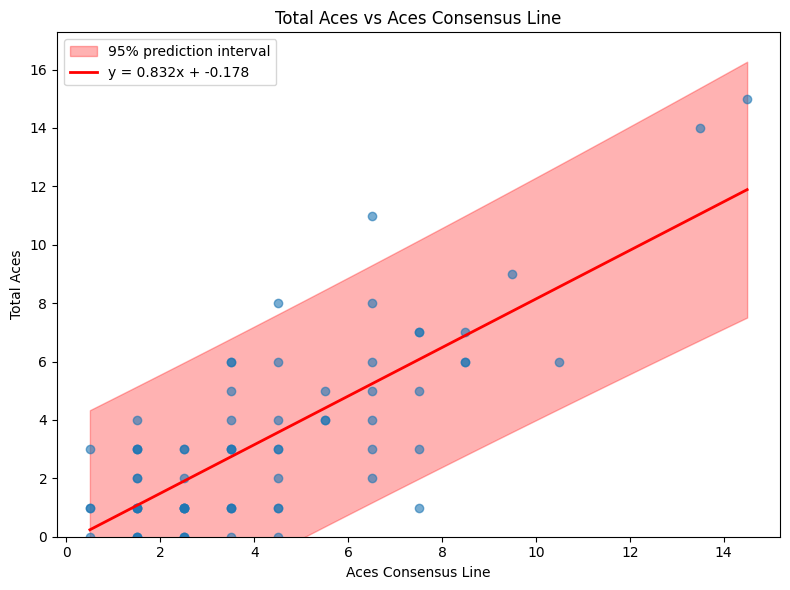

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

best_of_3_2_set_df = stats_and_odds_clean_df[
    (stats_and_odds_clean_df["mode_best_of"] == 3) &
    (stats_and_odds_clean_df["total_sets"] == 2)
]

x = pd.to_numeric(best_of_3_2_set_df["avg_closing_line_points"], errors="coerce").values
y = pd.to_numeric(best_of_3_2_set_df["total_aces"], errors="coerce").values
mask = np.isfinite(x) & np.isfinite(y)
x_clean = x[mask].reshape(-1, 1)
y_clean = y[mask]

n = len(y_clean)
reg = LinearRegression().fit(x_clean, y_clean)
y_pred = reg.predict(x_clean)
residuals = y_clean - y_pred
# Residual standard error
mse = np.sum(residuals**2) / (n - 2)
se_res = np.sqrt(mse)
# Standard error of prediction (for a new point): widens away from x mean
x_mean = x_clean.mean()
se_pred = se_res * np.sqrt(1 + 1/n + (x_clean.ravel() - x_mean)**2 / np.sum((x_clean.ravel() - x_mean)**2))

# Prediction interval (e.g. 95%): use t-distribution
from scipy import stats
t_val = stats.t.ppf(0.975, n - 2)
pred_upper = y_pred + t_val * se_pred
pred_lower = y_pred - t_val * se_pred

# For plotting: evaluate on a smooth x line
x_line = np.linspace(x_clean.min(), x_clean.max(), 200).reshape(-1, 1)
y_line = reg.predict(x_line)
se_pred_line = se_res * np.sqrt(1 + 1/n + (x_line.ravel() - x_mean)**2 / np.sum((x_clean.ravel() - x_mean)**2))
upper_line = y_line + t_val * se_pred_line
lower_line = y_line - t_val * se_pred_line

plt.figure(figsize=(8, 6))
plt.fill_between(x_line.ravel(), lower_line, upper_line, alpha=0.3, color="red", label="95% prediction interval")
plt.plot(x_line, y_line, color="red", linewidth=2, label=f"y = {reg.coef_[0]:.3f}x + {reg.intercept_:.3f}")
plt.scatter(x, y, alpha=0.6)
plt.ylim(bottom=0)
plt.xlabel("Aces Consensus Line")
plt.ylabel("Total Aces")
plt.title("Total Aces vs Aces Consensus Line")
plt.legend()
plt.tight_layout()
plt.show()

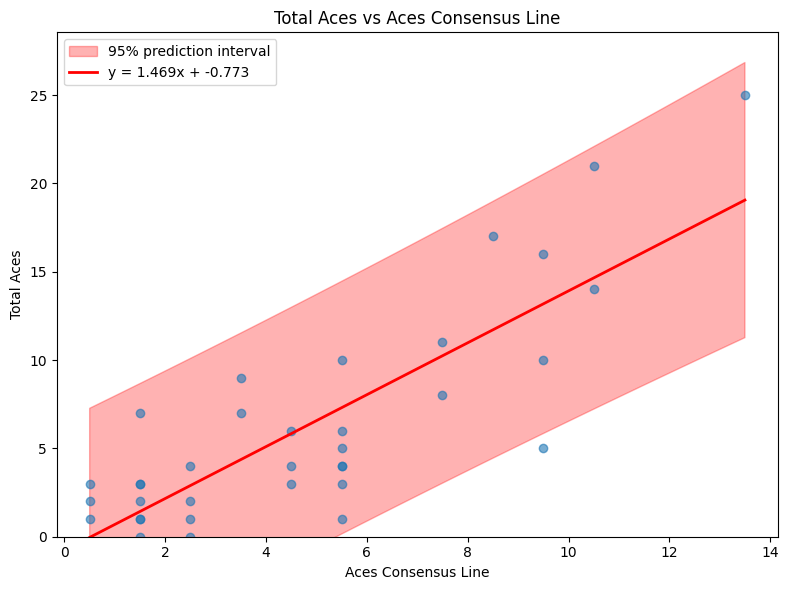

In [32]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

best_of_3_3_set_df = stats_and_odds_clean_df[
    (stats_and_odds_clean_df["mode_best_of"] == 3) &
    (stats_and_odds_clean_df["total_sets"] == 3)
]

x = pd.to_numeric(best_of_3_3_set_df["avg_closing_line_points"], errors="coerce").values
y = pd.to_numeric(best_of_3_3_set_df["total_aces"], errors="coerce").values
mask = np.isfinite(x) & np.isfinite(y)
x_clean = x[mask].reshape(-1, 1)
y_clean = y[mask]

n = len(y_clean)
reg = LinearRegression().fit(x_clean, y_clean)
y_pred = reg.predict(x_clean)
residuals = y_clean - y_pred
# Residual standard error
mse = np.sum(residuals**2) / (n - 2)
se_res = np.sqrt(mse)
# Standard error of prediction (for a new point): widens away from x mean
x_mean = x_clean.mean()
se_pred = se_res * np.sqrt(1 + 1/n + (x_clean.ravel() - x_mean)**2 / np.sum((x_clean.ravel() - x_mean)**2))

# Prediction interval (e.g. 95%): use t-distribution
from scipy import stats
t_val = stats.t.ppf(0.975, n - 2)
pred_upper = y_pred + t_val * se_pred
pred_lower = y_pred - t_val * se_pred

# For plotting: evaluate on a smooth x line
x_line = np.linspace(x_clean.min(), x_clean.max(), 200).reshape(-1, 1)
y_line = reg.predict(x_line)
se_pred_line = se_res * np.sqrt(1 + 1/n + (x_line.ravel() - x_mean)**2 / np.sum((x_clean.ravel() - x_mean)**2))
upper_line = y_line + t_val * se_pred_line
lower_line = y_line - t_val * se_pred_line

plt.figure(figsize=(8, 6))
plt.fill_between(x_line.ravel(), lower_line, upper_line, alpha=0.3, color="red", label="95% prediction interval")
plt.plot(x_line, y_line, color="red", linewidth=2, label=f"y = {reg.coef_[0]:.3f}x + {reg.intercept_:.3f}")
plt.scatter(x, y, alpha=0.6)
plt.ylim(bottom=0)
plt.xlabel("Aces Consensus Line")
plt.ylabel("Total Aces")
plt.title("Total Aces vs Aces Consensus Line")
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
stats_and_odds_clean_df[stats_and_odds_clean_df.mode_best_of == 3].value_counts('total_sets')

total_sets
2    70
3    35
Name: count, dtype: int64

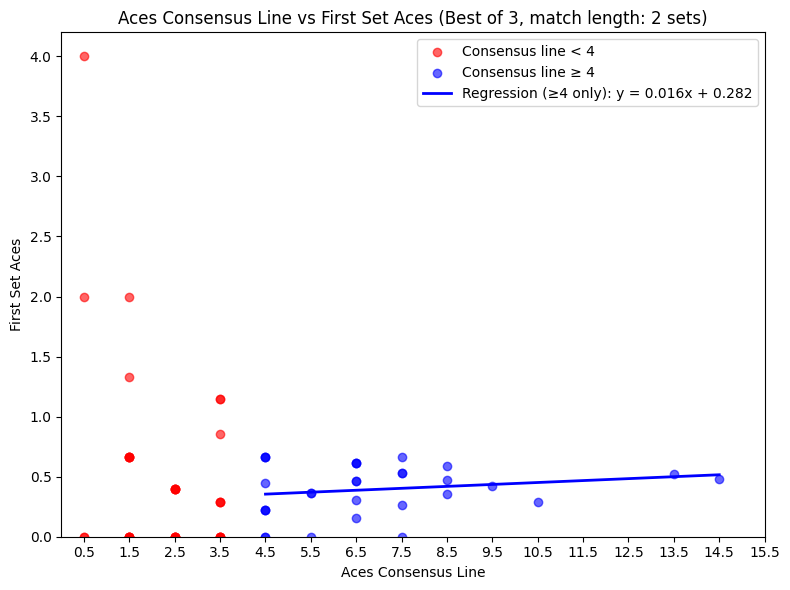

In [34]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

df_best_of_3_2set = stats_and_odds_clean_df[
    (stats_and_odds_clean_df["mode_best_of"] == 3) &
    (stats_and_odds_clean_df["total_sets"] == 2)
]

# Split by consensus line
below_4 = df_best_of_3_2set[df_best_of_3_2set["avg_closing_line_points"] < 4]
ge_4 = df_best_of_3_2set[df_best_of_3_2set["avg_closing_line_points"] >= 4]

# Regression only on data >= 4
x_ge4 = pd.to_numeric(ge_4["avg_closing_line_points"], errors="coerce").values
y_ge4 = pd.to_numeric(ge_4["1st set ace share by consensus"], errors="coerce").values
mask_ge4 = np.isfinite(x_ge4) & np.isfinite(y_ge4)
x_clean = x_ge4[mask_ge4].reshape(-1, 1)
y_clean = y_ge4[mask_ge4]

reg = LinearRegression().fit(x_clean, y_clean)
x_line = np.linspace(x_clean.min(), x_clean.max(), 100).reshape(-1, 1)
y_line = reg.predict(x_line)

plt.figure(figsize=(8, 6))
plt.scatter(
    below_4["avg_closing_line_points"],
    below_4["1st set ace share by consensus"],
    c="red",
    alpha=0.6,
    label="Consensus line < 4",
)
plt.scatter(
    ge_4["avg_closing_line_points"],
    ge_4["1st set ace share by consensus"],
    c="blue",
    alpha=0.6,
    label="Consensus line ≥ 4",
)
plt.plot(
    x_line,
    y_line,
    color="blue",
    linewidth=2,
    label=f"Regression (≥4 only): y = {reg.coef_[0]:.3f}x + {reg.intercept_:.3f}",
)
ax = plt.gca()
x_max = ax.get_xlim()[1]  # or set a fixed max if you prefer
ax.set_xticks(np.arange(0.5, x_max + 0.5, 1))
plt.xlabel("Aces Consensus Line")
plt.ylabel("First Set Aces")
plt.title("Aces Consensus Line vs First Set Aces (Best of 3, match length: 2 sets)")
plt.ylim(bottom=0)
plt.xlim(left=0)
plt.legend()
plt.tight_layout()
plt.show()

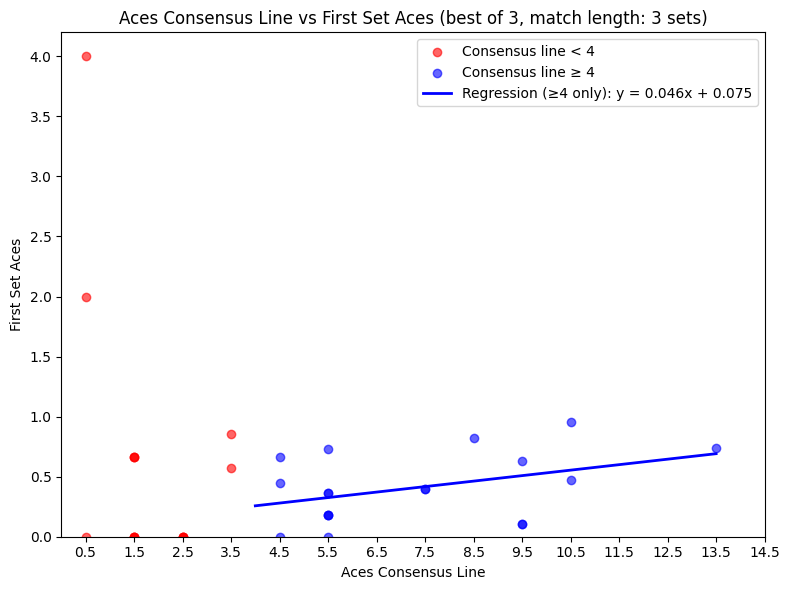

In [35]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

df_best_of_3_3set = stats_and_odds_clean_df[
    (stats_and_odds_clean_df["mode_best_of"] == 3) &
    (stats_and_odds_clean_df["total_sets"] == 3)
]

# Split by consensus line
below_4 = df_best_of_3_3set[df_best_of_3_3set["avg_closing_line_points"] < 4]
ge_4 = df_best_of_3_3set[df_best_of_3_3set["avg_closing_line_points"] >= 4]

# Regression only on data >= 4
x_ge4 = pd.to_numeric(ge_4["avg_closing_line_points"], errors="coerce").values
y_ge4 = pd.to_numeric(ge_4["1st set ace share by consensus"], errors="coerce").values
mask_ge4 = np.isfinite(x_ge4) & np.isfinite(y_ge4)
x_clean = x_ge4[mask_ge4].reshape(-1, 1)
y_clean = y_ge4[mask_ge4]

reg = LinearRegression().fit(x_clean, y_clean)
x_line = np.linspace(4, x_clean.max(), 100).reshape(-1, 1)
y_line = reg.predict(x_line)

plt.figure(figsize=(8, 6))
plt.scatter(
    below_4["avg_closing_line_points"],
    below_4["1st set ace share by consensus"],
    c="red",
    alpha=0.6,
    label="Consensus line < 4",
)
plt.scatter(
    ge_4["avg_closing_line_points"],
    ge_4["1st set ace share by consensus"],
    c="blue",
    alpha=0.6,
    label="Consensus line ≥ 4",
)
plt.plot(
    x_line,
    y_line,
    color="blue",
    linewidth=2,
    label=f"Regression (≥4 only): y = {reg.coef_[0]:.3f}x + {reg.intercept_:.3f}",
)
plt.xlabel("Aces Consensus Line")
plt.ylabel("First Set Aces")
plt.title("Aces Consensus Line vs First Set Aces (best of 3, match length: 3 sets)")
plt.xlim(left=0)
plt.ylim(bottom=0)
ax = plt.gca()
x_max = ax.get_xlim()[1]
ax.set_xticks(np.arange(0.5, x_max + 0.5, 1))
plt.legend()
plt.tight_layout()
plt.show()

_______

In [36]:
# Only working with actual play by play data here
best_of_3 = merged_ace_share[merged_ace_share.mode_best_of == 3]
best_of_3 = best_of_3[best_of_3.total_sets >= 2]

best_of_5 = merged_ace_share[merged_ace_share.mode_best_of == 5]
best_of_5 = best_of_5[best_of_5.total_sets >= 3]

Best of 3 1st Set Ace Share

In [37]:
# Splitting best of 3 matches based on length of match (2 and 3 set completion)
best_of_3_2set = best_of_3[best_of_3.total_sets == 2]
best_of_3_3set = best_of_3[best_of_3.total_sets == 3]


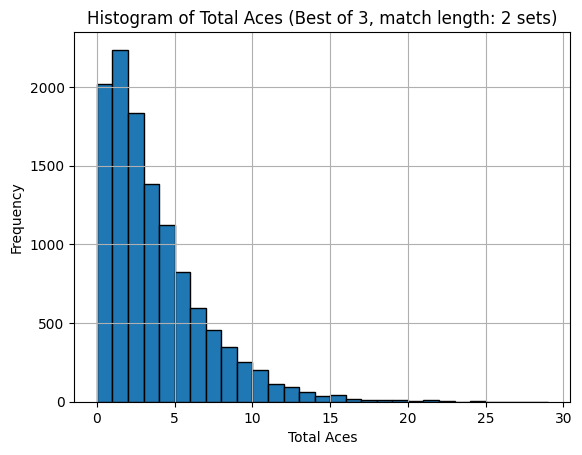

In [38]:
# histogram with increments of 1
best_of_3_2set["total_aces"].hist(bins=range(int(best_of_3_2set["total_aces"].min()), int(best_of_3_2set["total_aces"].max()) + 2, 1), edgecolor="black")
plt.xlabel("Total Aces")
plt.ylabel("Frequency")
plt.title("Histogram of Total Aces (Best of 3, match length: 2 sets)")
plt.show()


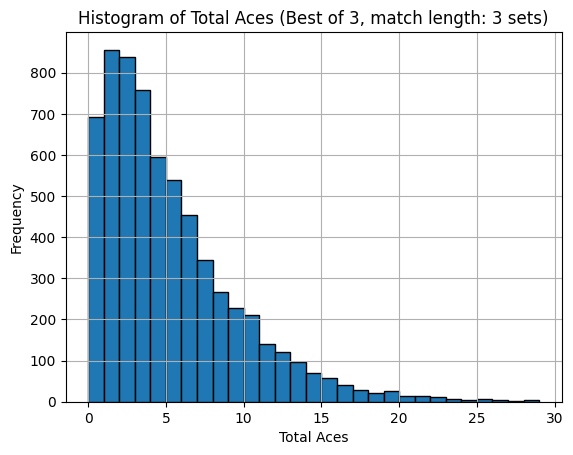

In [39]:
best_of_3_3set["total_aces"].hist(bins=range(int(best_of_3_2set["total_aces"].min()), int(best_of_3_2set["total_aces"].max()) + 2, 1), edgecolor="black")
plt.xlabel("Total Aces")
plt.ylabel("Frequency")
plt.title("Histogram of Total Aces (Best of 3, match length: 3 sets)")
plt.show()

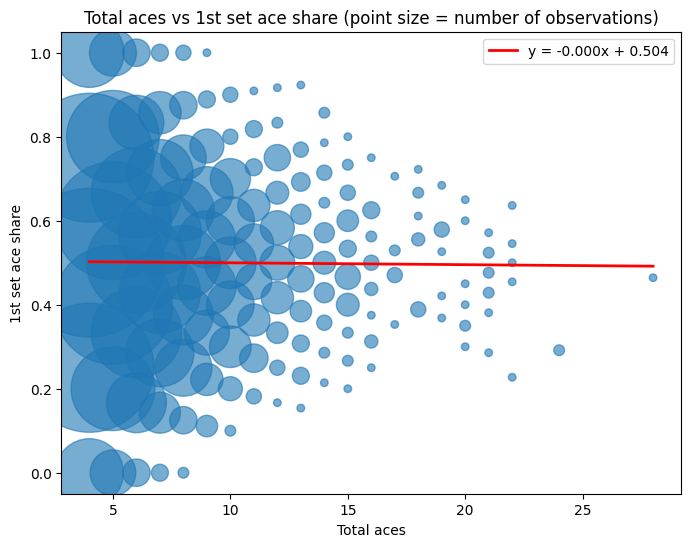

In [76]:
best_of_3_2set_over_4 = best_of_3_2set[best_of_3_2set["total_aces"] >= 4]

# Count observations per (total_aces, 1st set ace share)
counts = best_of_3_2set_over_4.groupby(["total_aces", "1st set ace share"]).size().reset_index(name="count")

plt.figure(figsize=(8, 6))
plt.scatter(
    counts["total_aces"],
    counts["1st set ace share"],
    s=counts["count"] * 30,
    alpha=0.6,
)

# Regression on raw data (total_aces >= 4)
x = pd.to_numeric(best_of_3_2set_over_4["total_aces"], errors="coerce").values
y = pd.to_numeric(best_of_3_2set_over_4["1st set ace share"], errors="coerce").values
mask = np.isfinite(x) & np.isfinite(y)
x_clean = x[mask].reshape(-1, 1)
y_clean = y[mask]

from sklearn.linear_model import LinearRegression
reg32 = LinearRegression().fit(x_clean, y_clean)
x_line = np.linspace(x_clean.min(), x_clean.max(), 100).reshape(-1, 1)
y_line = reg32.predict(x_line)
plt.plot(x_line, y_line, color="red", linewidth=2, label=f"y = {reg32.coef_[0]:.3f}x + {reg32.intercept_:.3f}")

plt.xlabel("Total aces")
plt.ylabel("1st set ace share")
plt.title("Total aces vs 1st set ace share (point size = number of observations)")
plt.legend()
plt.show()

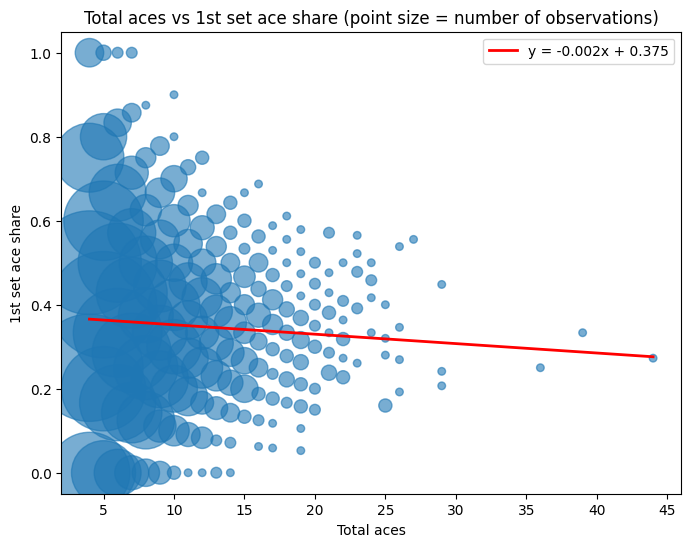

In [88]:
best_of_3_3set_over_4 = best_of_3_3set[best_of_3_3set["total_aces"] >= 4]

# Count observations per (total_aces, 1st set ace share)
counts = best_of_3_3set_over_4.groupby(["total_aces", "1st set ace share"]).size().reset_index(name="count")

plt.figure(figsize=(8, 6))
plt.scatter(
    counts["total_aces"],
    counts["1st set ace share"],
    s=counts["count"] * 30,
    alpha=0.6,
)

# Regression on raw data (total_aces >= 4)
x = pd.to_numeric(best_of_3_3set_over_4["total_aces"], errors="coerce").values
y = pd.to_numeric(best_of_3_3set_over_4["1st set ace share"], errors="coerce").values
mask = np.isfinite(x) & np.isfinite(y)
x_clean = x[mask].reshape(-1, 1)
y_clean = y[mask]

from sklearn.linear_model import LinearRegression
reg33 = LinearRegression().fit(x_clean, y_clean)
x_line = np.linspace(x_clean.min(), x_clean.max(), 100).reshape(-1, 1)
y_line = reg33.predict(x_line)
plt.plot(x_line, y_line, color="red", linewidth=2, label=f"y = {reg33.coef_[0]:.3f}x + {reg33.intercept_:.3f}")

pos = y_clean > 0
x_pos = x_clean[pos]
y_pos = y_clean[pos]
log_y = np.log(y_pos)

plt.xlabel("Total aces")
plt.ylabel("1st set ace share")
plt.title("Total aces vs 1st set ace share (point size = number of observations)")
plt.legend()
plt.show()

________
Modeling data distribution methods:
1. Mean regression & residual regression
2. MLE for joint approximation of mean and sd as function of total aces

Data limited to total aces over 4 to avoid unpredictable high variance of low ace levels skewing models

In [123]:
import numpy as np
import pandas as pd
from scipy import optimize
from sklearn.model_selection import train_test_split

# Start from full df with your columns
df = best_of_3_2set_over_4
x_col = "total_aces"
y_col = "1st set ace share"

# Drop rows missing x or y
data = df[[x_col, y_col]].dropna()

# Split by row indices so you keep dataframes
train_idx, test_idx = train_test_split(
    data.index, test_size=0.2, random_state=42
)
df_train = data.loc[train_idx]
df_test = data.loc[test_idx]

# Training arrays (flatten only when building the arrays)
x_train = pd.to_numeric(df_train[x_col], errors="coerce").values.reshape(-1, 1)
y_train = pd.to_numeric(df_train[y_col], errors="coerce").values
# Drop any new NaNs from to_numeric if needed
mask_train = np.isfinite(x_train).all(axis=1) & np.isfinite(y_train)
x_train = x_train[mask_train]
y_train = y_train[mask_train]

# Test arrays
x_test = pd.to_numeric(df_test[x_col], errors="coerce").values.reshape(-1, 1)
y_test = pd.to_numeric(df_test[y_col], errors="coerce").values
mask_test = np.isfinite(x_test).all(axis=1) & np.isfinite(y_test)
x_test = x_test[mask_test]
y_test = y_test[mask_test]

In [124]:
# Parameterize: μ(x) = beta0 + beta1*x,  σ(x) = exp(a + b*x) so σ > 0
def neg_log_likelihood(params):
    beta0, beta1, a, b = params
    mu = beta0 + beta1 * x_train.ravel()
    sigma = np.exp(a + b * x_train.ravel())
    sigma = np.maximum(sigma, 1e-6)
    nll = -np.sum(
        -0.5 * np.log(2 * np.pi) - np.log(sigma) - (y_train - mu) ** 2 / (2 * sigma**2)
    )
    return nll

# Initial guess: OLS for (beta0, beta1), constant sigma for (a, b)
resid_var = np.var(y_train - (y_train.mean() + 0 * x_train.ravel()))
init_beta0 = np.mean(y_train)
init_beta1 = 0.0
init_a = 0.5 * np.log(resid_var)
init_b = 0.0
x0 = [init_beta0, init_beta1, init_a, init_b]

result = optimize.minimize(neg_log_likelihood, x0, method="L-BFGS-B")
beta0_mle, beta1_mle, a_mle, b_mle = result.x

def mu_mle(x_new):
    """Predicted mean at new x."""
    x_new = np.asarray(x_new).ravel()
    return beta0_mle + beta1_mle * x_new

def sigma_mle(x_new):
    """Predicted std at new x."""
    x_new = np.asarray(x_new).ravel()
    return np.exp(a_mle + b_mle * x_new)

In [125]:
def log_likelihood_at(x_vals, y_vals, mu_func, sigma_func):
    """Average log-likelihood of y_vals under Normal(mu_func(x), sigma_func(x))."""
    mu = np.asarray(mu_func(x_vals)).ravel()
    sigma = np.asarray(sigma_func(x_vals)).ravel()
    sigma = np.maximum(sigma, 1e-6)
    return np.mean(
        -0.5 * np.log(2 * np.pi) - np.log(sigma) - (y_vals - mu) ** 2 / (2 * sigma**2)
    )

def interval_coverage(x_vals, y_vals, mu_func, sigma_func, z=1.645):
    """Fraction of y_vals in [μ - z*σ, μ + z*σ]. z=1.645 for ~90%, 0.674 for ~50%."""
    mu = np.asarray(mu_func(x_vals)).ravel()
    sigma = np.asarray(sigma_func(x_vals)).ravel()
    low, high = mu - z * sigma, mu + z * sigma
    return np.mean((y_vals >= low) & (y_vals <= high))

# Example: if you have a test set (x_test, y_test)
ll_mle  = log_likelihood_at(x_test, y_test, mu_mle, sigma_mle)
cov_mle = interval_coverage(x_test, y_test, mu_mle, sigma_mle, z=1.645)

print(f"Log Likelihood (MLE): {ll_mle}")
print(f"Coverage (MLE): {cov_mle}")

Log Likelihood (MLE): 0.10677634939382054
Coverage (MLE): 0.8911242603550296


Great coverage and log-likelihood for MLE. Visual evaluation below.

Log Likelihood (MLE): 0.10677634939382054
Coverage (MLE): 0.8911242603550296


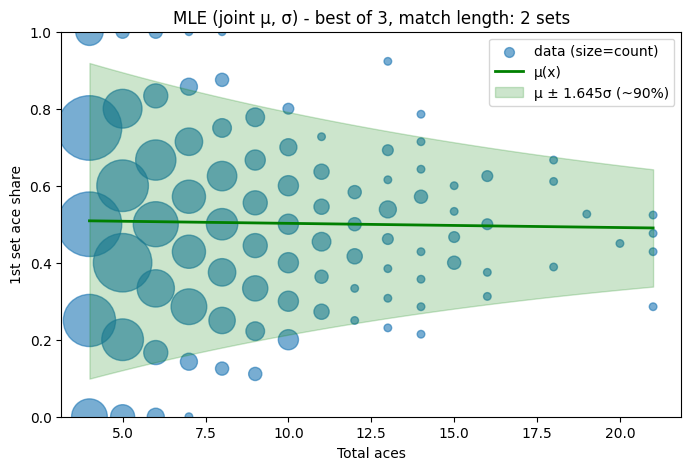

In [217]:
import numpy as np
import pandas as pd
from scipy import optimize
from sklearn.model_selection import train_test_split

# Start from full df with your columns
df = best_of_3_2set_over_4
x_col = "total_aces"
y_col = "1st set ace share"

# Drop rows missing x or y
data = df[[x_col, y_col]].dropna()

# Split by row indices so you keep dataframes
train_idx, test_idx = train_test_split(
    data.index, test_size=0.2, random_state=42
)
df_train = data.loc[train_idx]
df_test = data.loc[test_idx]

# Training arrays (flatten only when building the arrays)
x_train = pd.to_numeric(df_train[x_col], errors="coerce").values.reshape(-1, 1)
y_train = pd.to_numeric(df_train[y_col], errors="coerce").values
# Drop any new NaNs from to_numeric if needed
mask_train = np.isfinite(x_train).all(axis=1) & np.isfinite(y_train)
x_train = x_train[mask_train]
y_train = y_train[mask_train]

# Test arrays
x_test = pd.to_numeric(df_test[x_col], errors="coerce").values.reshape(-1, 1)
y_test = pd.to_numeric(df_test[y_col], errors="coerce").values
mask_test = np.isfinite(x_test).all(axis=1) & np.isfinite(y_test)
x_test = x_test[mask_test]
y_test = y_test[mask_test]

# Parameterize: μ(x) = beta0 + beta1*x,  σ(x) = exp(a + b*x) so σ > 0
def neg_log_likelihood(params):
    beta0, beta1, a, b = params
    mu = beta0 + beta1 * x_train.ravel()
    sigma = np.exp(a + b * x_train.ravel())
    sigma = np.maximum(sigma, 1e-6)
    nll = -np.sum(
        -0.5 * np.log(2 * np.pi) - np.log(sigma) - (y_train - mu) ** 2 / (2 * sigma**2)
    )
    return nll

# Initial guess: OLS for (beta0, beta1), constant sigma for (a, b)
resid_var = np.var(y_train - (y_train.mean() + 0 * x_train.ravel()))
init_beta0 = np.mean(y_train)
init_beta1 = 0.0
init_a = 0.5 * np.log(resid_var)
init_b = 0.0
x0 = [init_beta0, init_beta1, init_a, init_b]

result = optimize.minimize(neg_log_likelihood, x0, method="L-BFGS-B")
beta0_mle, beta1_mle, a_mle, b_mle = result.x

def mu_mle(x_new):
    """Predicted mean at new x."""
    x_new = np.asarray(x_new).ravel()
    return beta0_mle + beta1_mle * x_new

def sigma_mle(x_new):
    """Predicted std at new x."""
    x_new = np.asarray(x_new).ravel()
    return np.exp(a_mle + b_mle * x_new)

def log_likelihood_at(x_vals, y_vals, mu_func, sigma_func):
    """Average log-likelihood of y_vals under Normal(mu_func(x), sigma_func(x))."""
    mu = np.asarray(mu_func(x_vals)).ravel()
    sigma = np.asarray(sigma_func(x_vals)).ravel()
    sigma = np.maximum(sigma, 1e-6)
    return np.mean(
        -0.5 * np.log(2 * np.pi) - np.log(sigma) - (y_vals - mu) ** 2 / (2 * sigma**2)
    )

def interval_coverage(x_vals, y_vals, mu_func, sigma_func, z=1.645):
    """Fraction of y_vals in [μ - z*σ, μ + z*σ]. z=1.645 for ~90%, 0.674 for ~50%."""
    mu = np.asarray(mu_func(x_vals)).ravel()
    sigma = np.asarray(sigma_func(x_vals)).ravel()
    low, high = mu - z * sigma, mu + z * sigma
    return np.mean((y_vals >= low) & (y_vals <= high))

# Example: if you have a test set (x_test, y_test)
ll_mle  = log_likelihood_at(x_test, y_test, mu_mle, sigma_mle)
cov_mle = interval_coverage(x_test, y_test, mu_mle, sigma_mle, z=1.645)

print(f"Log Likelihood (MLE): {ll_mle}")
print(f"Coverage (MLE): {cov_mle}")

# Use test set (or concatenate train+test) for the scatter
x_plot = x_test.ravel()
y_plot = y_test

# Count observations at each (x, y) for point sizes
counts_df = pd.DataFrame({"x": x_plot, "y": y_plot}).groupby(["x", "y"]).size().reset_index(name="count")
x_scatter = counts_df["x"].values
y_scatter = counts_df["y"].values
sizes = counts_df["count"].values * 30  # scale; adjust as needed

# Smooth x grid for mean and interval curves
x_line = np.linspace(x_plot.min(), x_plot.max(), 200)
z = 1.645  # ~90% interval

# MLE (use _vals so mu_mle and sigma_mle stay as functions)
mu_mle_vals = mu_mle(x_line)
sigma_mle_vals = sigma_mle(x_line)
low_mle = mu_mle_vals - z * sigma_mle_vals
high_mle = mu_mle_vals + z * sigma_mle_vals

#  MLE Plot
plt.figure(figsize=(8, 5))
plt.scatter(x_scatter, y_scatter, s=sizes, alpha=0.6, label="data (size=count)")
plt.plot(x_line, mu_mle_vals, color="green", linewidth=2, label="μ(x)")
plt.fill_between(x_line, low_mle, high_mle, alpha=0.2, color="green", label=f"μ ± {z}σ (~90%)")
plt.xlabel("Total aces")
plt.ylabel("1st set ace share")
plt.title("MLE (joint μ, σ) - best of 3, match length: 2 sets")
leg = plt.legend()
leg.legend_handles[0].set_sizes([50])
plt.ylim(0, 1)

plt.show()

MLE captures tunneling variance. Will use this method going modeling 1st set ace share as a function of total aces.

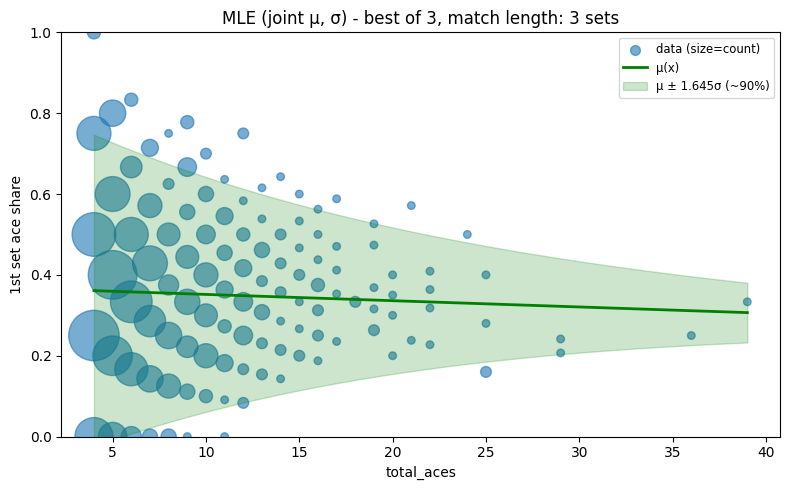

In [218]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scipy import optimize

# --- 1) Data: substitute your df and column names ---
df = best_of_3_3set_over_4
x_col = "total_aces"
y_col = "1st set ace share"
data = df[[x_col, y_col]].dropna()

# --- 2) Train/test split at dataframe level ---
train_idx, test_idx = train_test_split(data.index, test_size=0.2, random_state=42)
df_train = data.loc[train_idx]
df_test = data.loc[test_idx]

# --- 3) Extract arrays (training for fit, test for plot/eval) ---
x_train = pd.to_numeric(df_train[x_col], errors="coerce").values.reshape(-1, 1)
y_train = pd.to_numeric(df_train[y_col], errors="coerce").values
m = np.isfinite(x_train).all(axis=1) & np.isfinite(y_train)
x_train, y_train = x_train[m], y_train[m]

x_test = pd.to_numeric(df_test[x_col], errors="coerce").values.reshape(-1, 1)
y_test = pd.to_numeric(df_test[y_col], errors="coerce").values
m = np.isfinite(x_test).all(axis=1) & np.isfinite(y_test)
x_test, y_test = x_test[m], y_test[m]

# --- 4) MLE fit: μ(x)=β₀+β₁x, σ(x)=exp(a+b*x) ---
x_fit = x_train.ravel()
y_fit = y_train

def nll(params):
    b0, b1, a, b = params
    mu = b0 + b1 * x_fit
    sig = np.maximum(np.exp(a + b * x_fit), 1e-6)
    return -np.sum(-0.5 * np.log(2 * np.pi) - np.log(sig) - (y_fit - mu) ** 2 / (2 * sig**2))

init = [np.mean(y_fit), 0.0, 0.5 * np.log(np.var(y_fit)), 0.0]
b0, b1, a, b = optimize.minimize(nll, init, method="L-BFGS-B").x

def mu_mle(x): return b0 + b1 * np.asarray(x).ravel()
def sigma_mle(x): return np.exp(a + b * np.asarray(x).ravel())

# --- 5) Plot (test data, point size = count) ---
x_plot = x_test.ravel()
y_plot = y_test
counts = pd.DataFrame({"x": x_plot, "y": y_plot}).groupby(["x", "y"]).size().reset_index(name="count")
x_s, y_s = counts["x"].values, counts["y"].values
s_s = counts["count"].values * 30

x_line = np.linspace(x_plot.min(), x_plot.max(), 200)
z = 1.645
mu_line = mu_mle(x_line)
sig_line = sigma_mle(x_line)
low, high = mu_line - z * sig_line, mu_line + z * sig_line

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x_s, y_s, s=s_s, alpha=0.6, label="data (size=count)")
ax.plot(x_line, mu_line, color="green", linewidth=2, label="μ(x)")
ax.fill_between(x_line, low, high, alpha=0.2, color="green", label=f"μ ± {z}σ (~90%)")
ax.set_xlabel(x_col)
ax.set_ylabel(y_col)
ax.set_title("MLE (joint μ, σ) - best of 3, match length: 3 sets")
leg = ax.legend(fontsize="small")
leg.legend_handles[0].set_sizes([50]) 
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

__________

## Refactored MLE pipeline — 5 segments, standardized naming

Uses `best_of_3` and `best_of_5` (cleaned data with `total_aces`, `1st set ace share`, `total_sets`). Splits by match length, fits MLE per segment with distinct names, and stores results for later combined-distribution use.

In [146]:
from scipy import optimize
from sklearn.model_selection import train_test_split

# Column names used across all segments
X_COL = "total_aces"
Y_COL = "1st set ace share"

In [147]:
def prepare_xy_from_df(df, x_col, y_col, test_size=0.2, random_state=42):
    """Drop missing x/y, split by index, return train/test arrays and indices."""
    data = df[[x_col, y_col]].dropna()
    train_idx, test_idx = train_test_split(data.index, test_size=test_size, random_state=random_state)
    df_train = data.loc[train_idx]
    df_test = data.loc[test_idx]
    x_train = pd.to_numeric(df_train[x_col], errors="coerce").values.reshape(-1, 1)
    y_train = pd.to_numeric(df_train[y_col], errors="coerce").values
    x_test = pd.to_numeric(df_test[x_col], errors="coerce").values.reshape(-1, 1)
    y_test = pd.to_numeric(df_test[y_col], errors="coerce").values
    mask_train = np.isfinite(x_train).all(axis=1) & np.isfinite(y_train)
    mask_test = np.isfinite(x_test).all(axis=1) & np.isfinite(y_test)
    x_train = x_train[mask_train]
    y_train = y_train[mask_train]
    x_test = x_test[mask_test]
    y_test = y_test[mask_test]
    return x_train, y_train, x_test, y_test, train_idx, test_idx


def fit_mle_normal_heteroscedastic(x_train, y_train):
    """
    Fit μ(x)=β0+β1*x, σ(x)=exp(a+b*x). Returns (beta0, beta1, a, b).
    """
    def neg_log_likelihood(params):
        beta0, beta1, a, b = params
        mu = beta0 + beta1 * x_train.ravel()
        sigma = np.exp(a + b * x_train.ravel())
        sigma = np.maximum(sigma, 1e-6)
        nll = -np.sum(
            -0.5 * np.log(2 * np.pi) - np.log(sigma) - (y_train - mu) ** 2 / (2 * sigma**2)
        )
        return nll

    resid_var = np.var(y_train - (y_train.mean() + 0 * x_train.ravel()))
    init_beta0 = np.mean(y_train)
    init_beta1 = 0.0
    init_a = 0.5 * np.log(max(resid_var, 1e-10))
    init_b = 0.0
    x0 = [init_beta0, init_beta1, init_a, init_b]
    result = optimize.minimize(neg_log_likelihood, x0, method="L-BFGS-B")
    return result.x


def make_mu_sigma_functions(beta0, beta1, a, b):
    """Return (mu_func, sigma_func) for predicted mean and std at new x."""
    def mu_func(x_new):
        x_new = np.asarray(x_new).ravel()
        return beta0 + beta1 * x_new

    def sigma_func(x_new):
        x_new = np.asarray(x_new).ravel()
        return np.maximum(np.exp(a + b * x_new), 1e-6)

    return mu_func, sigma_func


def log_likelihood_at(x_vals, y_vals, mu_func, sigma_func):
    """Average log-likelihood of y_vals under Normal(mu_func(x), sigma_func(x))."""
    mu = np.asarray(mu_func(x_vals)).ravel()
    sigma = np.asarray(sigma_func(x_vals)).ravel()
    sigma = np.maximum(sigma, 1e-6)
    return np.mean(
        -0.5 * np.log(2 * np.pi) - np.log(sigma) - (y_vals - mu) ** 2 / (2 * sigma**2)
    )


def interval_coverage(x_vals, y_vals, mu_func, sigma_func, z=1.645):
    """Fraction of y_vals in [μ - z*σ, μ + z*σ]. z=1.645 ~90%, 0.674 ~50%."""
    mu = np.asarray(mu_func(x_vals)).ravel()
    sigma = np.asarray(sigma_func(x_vals)).ravel()
    low, high = mu - z * sigma, mu + z * sigma
    return np.mean((y_vals >= low) & (y_vals <= high))

In [148]:
best_of_3 = merged_ace_share[
    (merged_ace_share['mode_best_of'] == 3) & 
    (merged_ace_share['total_sets'] >= 2) &
    (merged_ace_share['total_aces'] > 4)
]

best_of_5 = merged_ace_share[
    (merged_ace_share['mode_best_of'] == 5) & 
    (merged_ace_share['total_sets'] >= 3) &
    (merged_ace_share['total_aces'] > 6)
]


In [149]:
# Segment datasets by match length (best_of_3 and best_of_5 already filtered for min sets)
segments = {
    "b3_2s": best_of_3[best_of_3.total_sets == 2],
    "b3_3s": best_of_3[best_of_3.total_sets == 3],
    "b5_3s": best_of_5[best_of_5.total_sets == 3],
    "b5_4s": best_of_5[best_of_5.total_sets == 4],
    "b5_5s": best_of_5[best_of_5.total_sets == 5],
}
for key, seg in segments.items():
    print(f"{key}: n = {len(seg)}")

b3_2s: n = 3102
b3_3s: n = 2715
b5_3s: n = 237
b5_4s: n = 231
b5_5s: n = 153


In [150]:
# Run MLE per segment; store params and predictor functions for combined distributions
mle_results = {}

for seg_key, seg_df in segments.items():
    if len(seg_df) < 10:  # skip if too few points
        print(f"{seg_key}: skipped (n={len(seg_df)})")
        continue
    x_train, y_train, x_test, y_test, train_idx, test_idx = prepare_xy_from_df(
        seg_df, X_COL, Y_COL
    )
    if len(x_train) < 5:
        print(f"{seg_key}: skipped (train n={len(x_train)})")
        continue
    beta0, beta1, a, b = fit_mle_normal_heteroscedastic(x_train, y_train)
    mu_func, sigma_func = make_mu_sigma_functions(beta0, beta1, a, b)
    ll = log_likelihood_at(x_test, y_test, mu_func, sigma_func)
    cov = interval_coverage(x_test, y_test, mu_func, sigma_func, z=1.645)
    mle_results[seg_key] = {
        "params": {"beta0": beta0, "beta1": beta1, "a": a, "b": b},
        "mu_func": mu_func,
        "sigma_func": sigma_func,
        "x_train": x_train,
        "y_train": y_train,
        "x_test": x_test,
        "y_test": y_test,
        "test_ll": ll,
        "test_coverage_90": cov,
        "n_train": len(x_train),
        "n_test": len(x_test),
    }
    print(f"{seg_key}: β0={beta0:.4f}, β1={beta1:.4f}, a={a:.4f}, b={b:.4f} | test_ll={ll:.4f}, cov90={cov:.3f}")

b3_2s: β0=0.5088, β1=-0.0009, a=-1.1984, b=-0.0557 | test_ll=0.1672, cov90=0.902
b3_3s: β0=0.3650, β1=-0.0016, a=-1.3055, b=-0.0451 | test_ll=0.2459, cov90=0.858
b5_3s: β0=0.3224, β1=0.0000, a=-1.3612, b=-0.0510 | test_ll=0.4567, cov90=0.896
b5_4s: β0=0.2137, β1=0.0020, a=-1.6021, b=-0.0313 | test_ll=0.4121, cov90=0.872
b5_5s: β0=0.1977, β1=-0.0006, a=-1.8374, b=-0.0263 | test_ll=0.8252, cov90=0.903


In [211]:
def plot_segment_coverage(mle_results, seg_key, z=1.645, ax=None, size_scale=30, ylim=(0, 1)):
    """
    Plot test data scatter, fitted μ(x), and prediction interval for one segment.
    If ax is None, creates a new figure. Returns the Axes.
    """
    if seg_key not in mle_results:
        return ax
    r = mle_results[seg_key]
    x_test = r["x_test"].ravel()
    y_test = r["y_test"]
    mu_func = r["mu_func"]
    sigma_func = r["sigma_func"]
    cov = r["test_coverage_90"]

    # Point sizes by count at each (x, y)
    counts_df = (
        pd.DataFrame({"x": x_test, "y": y_test})
        .groupby(["x", "y"])
        .size()
        .reset_index(name="count")
    )
    x_scatter = counts_df["x"].values
    y_scatter = counts_df["y"].values
    sizes = counts_df["count"].values * size_scale

    x_line = np.linspace(x_test.min(), x_test.max(), 200)
    mu_vals = mu_func(x_line)
    sigma_vals = sigma_func(x_line)
    low = mu_vals - z * sigma_vals
    high = mu_vals + z * sigma_vals

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(x_scatter, y_scatter, s=sizes, alpha=0.6, label="test data (size=count)")
    ax.plot(x_line, mu_vals, color="green", linewidth=2, label="μ(x)")
    ax.fill_between(
        x_line, low, high, alpha=0.2, color="green", label=f"μ ± {z}σ (~90%)"
    )
    ax.set_xlabel("Total aces")
    ax.set_ylabel("1st set ace share")
    ax.set_title(f"{seg_key} (n_test={len(y_test)}, cov90={cov:.3f})")
    # ax.legend(fontsize="small")
    leg = ax.legend(fontsize="small")
    leg.legend_handles[0].set_sizes([50]) 
    ax.set_ylim(ylim)
    return ax

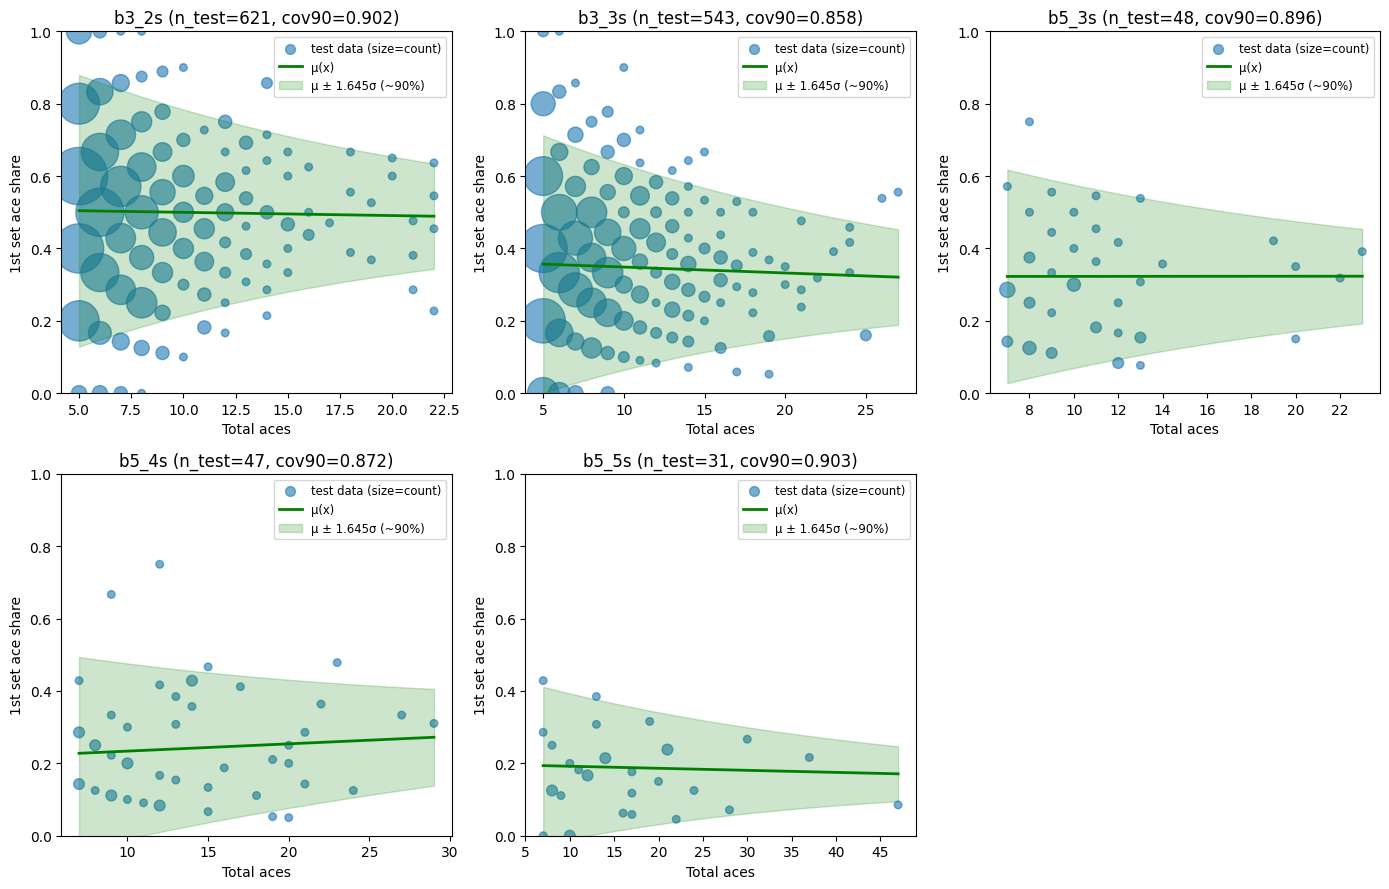

In [212]:
# Plot coverage on test data for all segments (2 rows × 3 cols; 5 segments)
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes_flat = axes.ravel()
for idx, seg_key in enumerate(mle_results):
    plot_segment_coverage(mle_results, seg_key, z=1.645, ax=axes_flat[idx])
# Hide the unused subplot (6th)
axes_flat[-1].set_visible(False)
plt.tight_layout()
plt.show()

In [174]:
# Summary: segment keys and test metrics (for combined-distribution step, use mle_results[seg_key]["mu_func"] etc.)
summary_df = pd.DataFrame(
    [
        {
            "segment": k,
            "n_train": v["n_train"],
            "n_test": v["n_test"],
            "test_ll": v["test_ll"],
            "cov_90": v["test_coverage_90"],
        }
        for k, v in mle_results.items()
    ]
)
summary_df

,segment,n_train,n_test,test_ll,cov_90
0,b3_2s,2481,621,0.167201,0.901771
1,b3_3s,2172,543,0.245930,0.858195
2,b5_3s,189,48,0.456653,0.895833
3,b5_4s,184,47,0.412130,0.872340
4,b5_5s,122,31,0.825204,0.903226


## Combined distribution (mixture by match length)

**Process:**
1. **Weights**: From observed data, compute the proportion of matches in each segment (e.g. 2-set vs 3-set for best-of-3). These weights are fixed and used for all lines.
2. **Given (line, best_of)**: Select the segment keys for that format (b3_2s, b3_3s for best_of=3; b5_3s, b5_4s, b5_5s for best_of=5). At the given total-aces line, evaluate each segment’s MLE to get (μ_i, σ_i). The combined distribution is a **mixture of normals**: PDF(y) = Σ w_i · φ(y; μ_i, σ_i), with the precomputed w_i.
3. **Output**: Reusable function returns mixture components and a callable PDF so we can evaluate likelihood on heldout (line, best_of, 1st-set-ace-share) and test calibration.

In [158]:
from scipy.stats import norm

# Segment keys per format (used for lookup and weight ordering)
BEST_OF_3_KEYS = ["b3_2s", "b3_3s"]
BEST_OF_5_KEYS = ["b5_3s", "b5_4s", "b5_5s"]


def compute_segment_weights(segments):
    """
    Compute weights from observed match-length counts. Returns dict:
    {3: {"b3_2s": w1, "b3_3s": w2}, 5: {"b5_3s": w1, "b5_4s": w2, "b5_5s": w3}}
    Weights sum to 1 within each best_of.
    """
    weights = {}
    for best_of, keys in [(3, BEST_OF_3_KEYS), (5, BEST_OF_5_KEYS)]:
        counts = [len(segments[k]) for k in keys]
        total = sum(counts)
        weights[best_of] = {k: (len(segments[k]) / total if total > 0 else 0.0) for k in keys}
    return weights


segment_weights = compute_segment_weights(segments)
for best_of in (3, 5):
    print(f"best_of={best_of}: {segment_weights[best_of]}")

best_of=3: {'b3_2s': 0.5332645693656524, 'b3_3s': 0.4667354306343476}
best_of=5: {'b5_3s': 0.38164251207729466, 'b5_4s': 0.3719806763285024, 'b5_5s': 0.2463768115942029}


In [159]:
def get_combined_distribution(line, best_of, mle_results, segment_weights):
    """
    Build the mixture-of-normals distribution for 1st set ace share given a total aces line
    and match format (best_of 3 or 5). Weights are proportional to observed match lengths.

    Parameters
    ----------
    line : float
        Total aces line (e.g. consensus line).
    best_of : int
        3 or 5.
    mle_results : dict
        Segment MLE results (mu_func, sigma_func per segment key).
    segment_weights : dict
        Weights per best_of, e.g. segment_weights[3] = {"b3_2s": w1, "b3_3s": w2}.

    Returns
    -------
    dict with keys:
        segment_keys, weights, means, stds (lists),
        mixture_mean, mixture_var (scalars),
        pdf(y), log_pdf(y) (callables).
    """
    line = float(line)
    keys = BEST_OF_3_KEYS if best_of == 3 else BEST_OF_5_KEYS
    if best_of not in segment_weights:
        raise ValueError(f"best_of must be 3 or 5, got {best_of}")

    available = [k for k in keys if k in mle_results]
    if not available:
        raise ValueError(f"No MLE results for best_of={best_of} (keys {keys})")

    w_dict = segment_weights[best_of]
    weights_list = [w_dict[k] for k in available]
    total_w = sum(weights_list)
    weights_list = [w / total_w for w in weights_list]

    means_list = []
    stds_list = []
    for k in available:
        mu_func = mle_results[k]["mu_func"]
        sigma_func = mle_results[k]["sigma_func"]
        _mu = np.asarray(mu_func(line)).ravel()
        _sig = np.asarray(sigma_func(line)).ravel()
        means_list.append(float(_mu[0]))
        stds_list.append(float(_sig[0]))

    weights_arr = np.array(weights_list)
    means_arr = np.array(means_list)
    stds_arr = np.array(stds_list)

    mixture_mean = float(np.dot(weights_arr, means_arr))
    mixture_var = float(
        np.dot(weights_arr, stds_arr**2 + means_arr**2) - mixture_mean**2
    )
    mixture_var = max(mixture_var, 1e-10)

    def pdf(y):
        y = np.asarray(y)
        out = np.zeros_like(y, dtype=float)
        for i in range(len(available)):
            out += weights_list[i] * norm.pdf(y, means_list[i], stds_list[i])
        return out.squeeze()

    def log_pdf(y):
        return np.log(np.maximum(pdf(y), 1e-300))

    return {
        "segment_keys": available,
        "weights": weights_list,
        "means": means_list,
        "stds": stds_list,
        "mixture_mean": mixture_mean,
        "mixture_var": mixture_var,
        "pdf": pdf,
        "log_pdf": log_pdf,
    }

In [167]:
# Quick test: combined distribution at one line for best-of-3 and best-of-5
test_line = 6.5
for bo in (3, 5):
    dist = get_combined_distribution(test_line, bo, mle_results, segment_weights)
    print(f"best_of={bo}, line={test_line}: mixture_mean={dist['mixture_mean']:.4f}, mixture_std={np.sqrt(dist['mixture_var']):.4f}")
    print(f"  components: {dist['segment_keys']} -> means={[f'{m:.3f}' for m in dist['means']]}, weights={[f'{w:.3f}' for w in dist['weights']]}")

best_of=3, line=6.5: mixture_mean=0.4336, mixture_std=0.2193
  components: ['b3_2s', 'b3_3s'] -> means=['0.503', '0.354'], weights=['0.533', '0.467']
best_of=5, line=6.5: mixture_mean=0.2553, mixture_std=0.1743
  components: ['b5_3s', 'b5_4s', 'b5_5s'] -> means=['0.323', '0.227', '0.194'], weights=['0.382', '0.372', '0.246']


In [168]:
def evaluate_combined_on_heldout(heldout_df, mle_results, segment_weights, x_col="total_aces", y_col="1st set ace share", best_of_col="mode_best_of"):
    """
    Score heldout data under the combined mixture distribution. Each row should have
    total aces line, actual 1st set ace share, and best_of (3 or 5).

    Returns mean log-likelihood (average log_pdf) and optional per-row log_pdf array.
    """
    log_pdfs = []
    for _, row in heldout_df.iterrows():
        line = float(row[x_col])
        y = float(row[y_col])
        best_of = int(row[best_of_col])
        if best_of not in (3, 5):
            continue
        dist = get_combined_distribution(line, best_of, mle_results, segment_weights)
        lp = float(dist["log_pdf"](y))
        log_pdfs.append(lp)
    if not log_pdfs:
        return np.nan, np.array([])
    return np.mean(log_pdfs), np.array(log_pdfs)


# Build heldout from segment test sets (each row: line, y, best_of)
heldout_rows = []
for seg_key, r in mle_results.items():
    best_of = 3 if seg_key.startswith("b3") else 5
    for line, y in zip(r["x_test"].ravel(), r["y_test"]):
        heldout_rows.append({"total_aces": line, "1st set ace share": y, "mode_best_of": best_of})
heldout_df = pd.DataFrame(heldout_rows)
mean_ll, per_row_ll = evaluate_combined_on_heldout(heldout_df, mle_results, segment_weights, x_col="total_aces", y_col="1st set ace share", best_of_col="mode_best_of")
print(f"Heldout mean log-likelihood (combined distribution): {mean_ll:.4f}")
print(f"Heldout n = {len(per_row_ll)}")

Heldout mean log-likelihood (combined distribution): 0.1861
Heldout n = 1290


## First set aces line and distribution plot

- **First set line**: Point estimate = total aces line × mixture mean (1st set ace share).
- **Plot**: Distribution of 1st set aces (mean and std converted from share to actual aces: mean_aces = line × μ, std_aces = line × σ).

In [202]:
def first_set_aces_line(line, best_of, mle_results, segment_weights):
    """
    Expected 1st set aces = total aces line × mixture mean (1st set ace share).
    Returns a scalar.
    """
    dist = get_combined_distribution(line, best_of, mle_results, segment_weights)
    return line * dist["mixture_mean"]


def half_increment_line_and_pmore(mean_aces, std_aces, round_down=True):
    """
    Betting line at half-increment (0.5, 1.5, 2.5, ...), never a whole number.
    round_down is ignored; we always round to the nearest half.
    Returns (line_half, p_more).
    """
    # Nearest half in {0.5, 1.5, 2.5, ...}: round(mean_aces - 0.5) + 0.5, clamp to 0.5 minimum
    line_half = max(0.5, np.round(mean_aces - 0.5) + 0.5)
    p_more = float(norm.sf(line_half, mean_aces, std_aces))
    return line_half, p_more


def plot_first_set_aces_distribution(
    line,
    best_of,
    mle_results,
    segment_weights,
    ax=None,
    n_points=300,
    z=1.645,
    round_down=True,
):
    """
    Plot the combined distribution in 1st set aces (not share).
    Converts mixture mean and std from share to aces.
    Shows the half-increment betting line and p-more (P(aces > line)) used to set payout.
    """
    dist = get_combined_distribution(line, best_of, mle_results, segment_weights)
    mu_share = dist["mixture_mean"]
    sigma_share = np.sqrt(dist["mixture_var"])
    mean_aces = line * mu_share
    std_aces = line * sigma_share

    line_half, p_more = half_increment_line_and_pmore(mean_aces, std_aces, round_down=round_down)

    # Grid of 1st set aces values (clip to [0, line] for realism)
    aces_min = max(0, mean_aces - 4 * std_aces)
    aces_max = min(line, mean_aces + 4 * std_aces)
    aces_grid = np.linspace(aces_min, aces_max, n_points)
    pdf_aces = norm.pdf(aces_grid, mean_aces, std_aces)

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(aces_grid, pdf_aces, color="green", linewidth=2, label="PDF (1st set aces)")
    # Half-increment betting line and p-more (shade "over" region)
    ax.axvline(line_half, color="navy", linewidth=2, linestyle="-", label=f"line = {line_half} aces")
    mask_more = aces_grid > line_half
    ax.fill_between(aces_grid, 0, pdf_aces, where=mask_more, alpha=0.25, color="navy", label=f"p-more = {p_more:.3f}")
    y_max = pdf_aces.max()
    ax.text(line_half, y_max * 0.5, f"  line = {line_half}\n  p-more = {p_more:.3f}", fontsize=9, color="navy", va="top")

    ax.set_xlabel("1st set aces")
    ax.set_ylabel("Density")
    ax.set_title(f"Total Game Aces = {line}, best_of = {best_of} (μ = {mean_aces:.2f}, σ = {std_aces:.2f})")
    ax.legend(fontsize="small")
    ax.set_ylim(0, None)
    return ax

Total aces line = 12.5, best_of = 3 -> mean 1st set aces = 5.33
Betting line (half-increment) = 5.5, p-more = 0.468


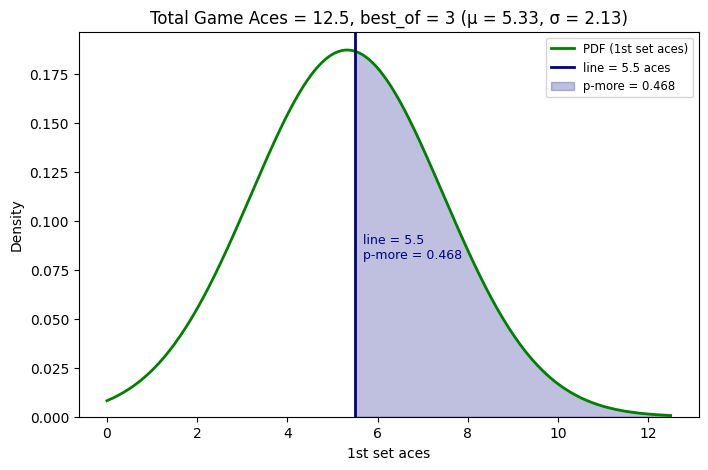

In [203]:
# Example: first set aces line, half-increment betting line, and p-more
example_line = 12.5
example_best_of = 3
first_set_line = first_set_aces_line(example_line, example_best_of, mle_results, segment_weights)
dist = get_combined_distribution(example_line, example_best_of, mle_results, segment_weights)
mean_aces = example_line * dist["mixture_mean"]
std_aces = example_line * np.sqrt(dist["mixture_var"])
line_half, p_more = half_increment_line_and_pmore(mean_aces, std_aces, round_down=True)
print(f"Total aces line = {example_line}, best_of = {example_best_of} -> mean 1st set aces = {first_set_line:.2f}")
print(f"Betting line (half-increment) = {line_half}, p-more = {p_more:.3f}")

plot_first_set_aces_distribution(example_line, example_best_of, mle_results, segment_weights)
plt.show()

______

In [219]:
def plot_first_set_aces_subdistributions(
    line,
    best_of,
    mle_results,
    segment_weights,
    ax=None,
    n_points=300,
    show_line_half=True,
):
    """
    Plot the component (sub-)distributions of 1st set aces assuming each match length,
    before combining. For best_of=3: 2-set and 3-set; for best_of=5: 3-, 4-, 5-set.
    Optional vertical line at the half-increment betting line for consistency with the combined plot.
    """
    line = float(line)
    keys = BEST_OF_3_KEYS if best_of == 3 else BEST_OF_5_KEYS
    if best_of not in segment_weights:
        return ax

    w_dict = segment_weights[best_of]
    colors = ["C0", "C1", "C2"]  # distinct colors for up to 3 components
    labels_map = {"b3_2s": "2 sets", "b3_3s": "3 sets", "b5_3s": "3 sets", "b5_4s": "4 sets", "b5_5s": "5 sets"}

    means_aces = []
    stds_aces = []
    for k in keys:
        if k not in mle_results:
            continue
        mu_share = np.asarray(mle_results[k]["mu_func"](line)).ravel()[0]
        sig_share = np.asarray(mle_results[k]["sigma_func"](line)).ravel()[0]
        means_aces.append(line * mu_share)
        stds_aces.append(line * sig_share)

    if not means_aces:
        return ax

    aces_min = max(0, min(means_aces) - 4 * max(stds_aces))
    aces_max = min(line, max(means_aces) + 4 * max(stds_aces))
    aces_grid = np.linspace(aces_min, aces_max, n_points)

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    for i, k in enumerate(keys):
        if k not in mle_results:
            continue
        w = w_dict.get(k, 0)
        mu_a = means_aces[i]
        sig_a = stds_aces[i]
        pdf_vals = norm.pdf(aces_grid, mu_a, sig_a)
        label = f"{labels_map.get(k, k)} (w={w:.2f})"
        ax.plot(aces_grid, pdf_vals, color=colors[i % len(colors)], linewidth=2, label=label)

    if show_line_half:
        dist = get_combined_distribution(line, best_of, mle_results, segment_weights)
        mean_aces = line * dist["mixture_mean"]
        std_aces = line * np.sqrt(dist["mixture_var"])
        line_half, p_more = half_increment_line_and_pmore(mean_aces, std_aces)
        ax.axvline(line_half, color="navy", linewidth=1.5, linestyle="--", alpha=0.8, label=f"line = {line_half}")

    ax.set_xlabel("1st set aces")
    ax.set_ylabel("Density")
    ax.set_title(f"Sub-distributions (conditional on match length) | Total aces line = {line}, best_of = {best_of}")
    ax.legend(fontsize="small")
    ax.set_ylim(0, None)
    return ax

Total aces line = 15.5, best_of = 5 -> mean 1st set aces = 4.04
Betting line (half-increment) = 4.5, p-more = 0.409


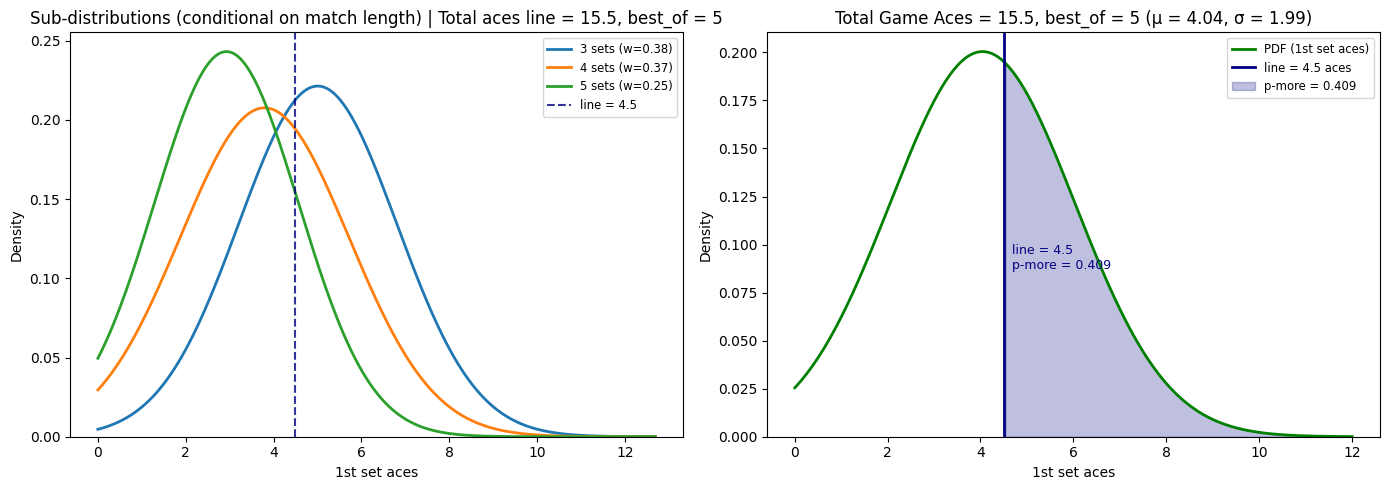

In [232]:
# Example: first set aces line, half-increment betting line, and p-more
example_line = 15.5
example_best_of = 5
first_set_line = first_set_aces_line(example_line, example_best_of, mle_results, segment_weights)
dist = get_combined_distribution(example_line, example_best_of, mle_results, segment_weights)
mean_aces = example_line * dist["mixture_mean"]
std_aces = example_line * np.sqrt(dist["mixture_var"])
line_half, p_more = half_increment_line_and_pmore(mean_aces, std_aces, round_down=True)
print(f"Total aces line = {example_line}, best_of = {example_best_of} -> mean 1st set aces = {first_set_line:.2f}")
print(f"Betting line (half-increment) = {line_half}, p-more = {p_more:.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
plot_first_set_aces_subdistributions(example_line, example_best_of, mle_results, segment_weights, ax=ax1, show_line_half=True)
plot_first_set_aces_distribution(example_line, example_best_of, mle_results, segment_weights, ax=ax2)
plt.tight_layout()
plt.show()

______
Calibration Plots

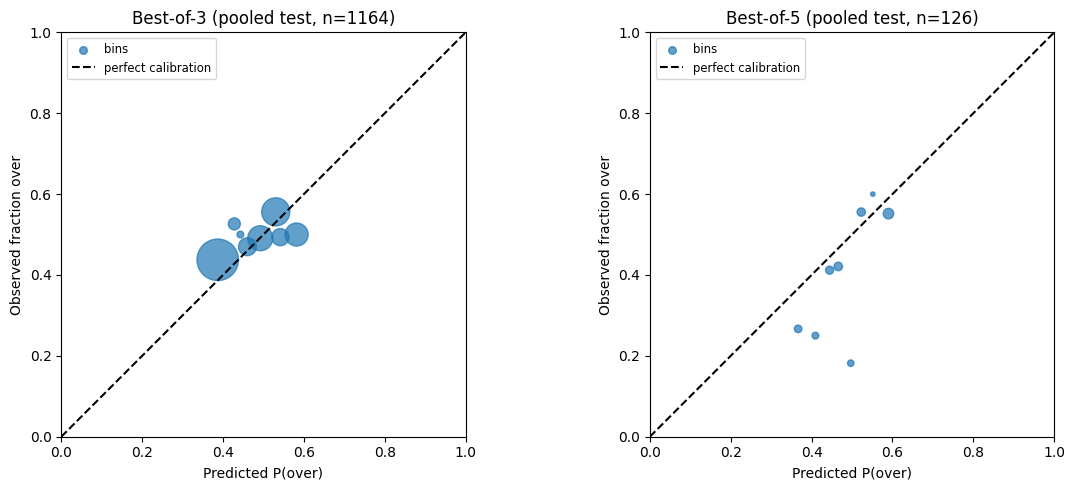

In [230]:
# Build pooled test data from segment MLE test sets (no OddsJam lines)
def build_pooled_test_df(mle_results, best_of):
    """Pool x_test, y_test from segments for this format. Returns df with line, actual_1st_set_aces, best_of."""
    keys = BEST_OF_3_KEYS if best_of == 3 else BEST_OF_5_KEYS
    rows = []
    for k in keys:
        if k not in mle_results:
            continue
        r = mle_results[k]
        x = r["x_test"].ravel()
        y = r["y_test"]
        # line = total aces; 1st set ace share = y; actual 1st set aces = line * share
        actual_aces = x * y
        for line, aces in zip(x, actual_aces):
            rows.append({"line": line, "actual_1st_set_aces": aces, "best_of": best_of})
    return pd.DataFrame(rows)

pool_b3 = build_pooled_test_df(mle_results, 3)
pool_b5 = build_pooled_test_df(mle_results, 5)

def add_combined_model_predictions(pool_df, mle_results, segment_weights):
    """Add line_half, p_more, over (actual > line_half) using combined distribution."""
    mean_aces_list = []
    std_aces_list = []
    line_half_list = []
    p_more_list = []
    for _, row in pool_df.iterrows():
        line = row["line"]
        best_of = row["best_of"]
        dist = get_combined_distribution(line, best_of, mle_results, segment_weights)
        mean_aces = line * dist["mixture_mean"]
        std_aces = line * np.sqrt(dist["mixture_var"])
        lh, pm = half_increment_line_and_pmore(mean_aces, std_aces)
        mean_aces_list.append(mean_aces)
        std_aces_list.append(std_aces)
        line_half_list.append(lh)
        p_more_list.append(pm)
    out = pool_df.copy()
    out["mean_aces"] = mean_aces_list
    out["std_aces"] = std_aces_list
    out["line_half"] = line_half_list
    out["p_more"] = p_more_list
    out["over"] = (out["actual_1st_set_aces"] > out["line_half"]).astype(float)
    return out

pool_b3 = add_combined_model_predictions(pool_b3, mle_results, segment_weights)
pool_b5 = add_combined_model_predictions(pool_b5, mle_results, segment_weights)

# Calibration: bin by predicted p_more, plot mean(p_more) vs observed fraction over
def calibration_plot_one(ax, df, title, n_bins=8):
    if len(df) < n_bins:
        n_bins = max(3, len(df) // 2)
    df = df.copy()
    df["p_more_bin"] = pd.cut(df["p_more"], bins=n_bins, include_lowest=True)
    cal = df.groupby("p_more_bin", observed=True).agg(
        mean_p_more=("p_more", "mean"),
        obs_over=("over", "mean"),
        count=("over", "count"),
    ).reset_index()
    ax.scatter(cal["mean_p_more"], cal["obs_over"], s=cal["count"] * 2, alpha=0.7, label="bins")
    ax.plot([0, 1], [0, 1], "k--", label="perfect calibration")
    ax.set_xlabel("Predicted P(over)")
    ax.set_ylabel("Observed fraction over")
    ax.set_title(title)
    leg = ax.legend(fontsize="small")
    leg.legend_handles[0].set_sizes([30])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
calibration_plot_one(ax1, pool_b3, f"Best-of-3 (pooled test, n={len(pool_b3)})")
calibration_plot_one(ax2, pool_b5, f"Best-of-5 (pooled test, n={len(pool_b5)})")
plt.tight_layout()
plt.show()

In [227]:
pool_b3.head()

,line,actual_1st_set_aces,best_of,mean_aces,std_aces,line_half,p_more,over
0,5,2.0,3,2.177362,1.173241,2.5,0.391659,0.0
1,5,4.0,3,2.177362,1.173241,2.5,0.391659,1.0
2,9,8.0,3,3.874613,1.769846,3.5,0.583816,1.0
3,15,7.0,3,6.346094,2.322253,6.5,0.473580,1.0
4,5,2.0,3,2.177362,1.173241,2.5,0.391659,0.0


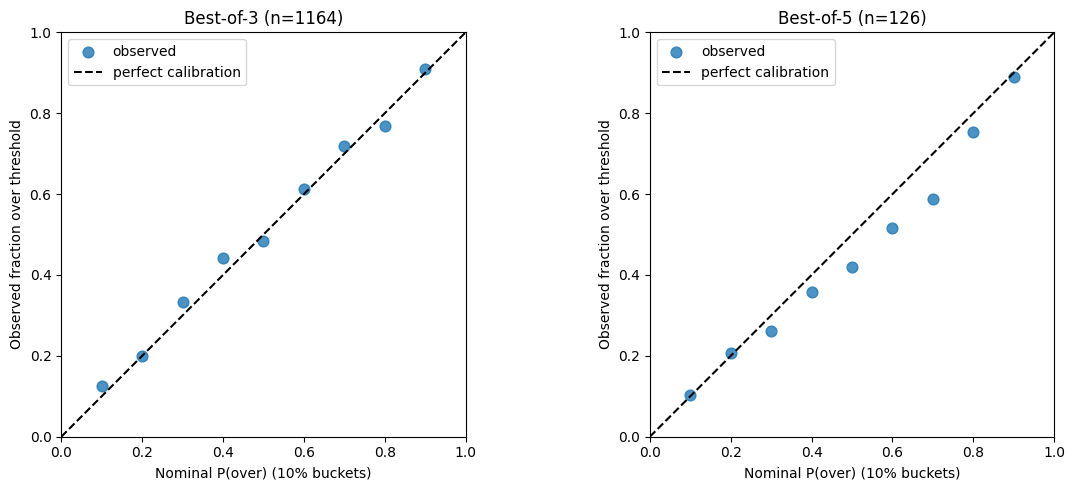

In [228]:
# Calibration at fixed 10% p-over buckets (per-distribution thresholds)
# For each row: from its combined distribution, get the ace line L_p where P(actual > L_p) = p.
# Then compute: what fraction of actuals were > L_p? Should ≈ p if well calibrated.

def calibration_at_deciles(pool_df, mle_results, segment_weights):
    """
    pool_df must have columns: line, actual_1st_set_aces, best_of.
    Returns (deciles, observed_fractions) for p in 0.1, 0.2, ..., 0.9.
    """
    p_buckets = np.arange(0.1, 1.0, 0.1)  # 0.1, 0.2, ..., 0.9
    observed = []
    for p in p_buckets:
        # For each row: L_p such that P(X > L_p) = p  =>  L_p = (1-p)-quantile = ppf(1-p)
        over_count = 0
        for _, row in pool_df.iterrows():
            line = row["line"]
            best_of = row["best_of"]
            dist = get_combined_distribution(line, best_of, mle_results, segment_weights)
            mean_aces = line * dist["mixture_mean"]
            std_aces = line * np.sqrt(dist["mixture_var"])
            L_p = norm.ppf(1 - p, mean_aces, std_aces)
            if row["actual_1st_set_aces"] > L_p:
                over_count += 1
        observed.append(over_count / len(pool_df))
    return p_buckets, np.array(observed)

# Pooled test data (same as before)
pool_b3 = build_pooled_test_df(mle_results, 3)
pool_b5 = build_pooled_test_df(mle_results, 5)

deciles = np.arange(0.1, 1.0, 0.1)
obs_b3 = calibration_at_deciles(pool_b3, mle_results, segment_weights)[1]
obs_b5 = calibration_at_deciles(pool_b5, mle_results, segment_weights)[1]

def plot_calibration_deciles(ax, deciles, observed, title, n):
    ax.scatter(deciles, observed, s=60, alpha=0.8, label="observed")
    ax.plot([0, 1], [0, 1], "k--", label="perfect calibration")
    ax.set_xlabel("Nominal P(over) (10% buckets)")
    ax.set_ylabel("Observed fraction over threshold")
    ax.set_title(f"{title} (n={n})")
    ax.legend()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
plot_calibration_deciles(ax1, deciles, obs_b3, "Best-of-3", len(pool_b3))
plot_calibration_deciles(ax2, deciles, obs_b5, "Best-of-5", len(pool_b5))
plt.tight_layout()
plt.show()